<center>
    
# A Reinforcement Learning Agent Solving A Two-Room Gridworld Challenge Using Q-Learning And Adopting An Objective-Oriented RL Reward Design
### **by P. Trujillo V. (pe.trujillo@uniandes.edu.co)** 
#### Reinforcement Learning 1 - Universidad de los Andes

</center>

<!-- ## Para un Two-Room Gridworld con Sub-tareas Secuenciales 
 -->

![proyect_agent_env_image](assets/proyect_agent_env_image.png)


---


**Table of Contents**

1. [Environment Description](#Environment-Description)
2. [Board Representation](#Board-Representation)
3. [MDP Definition](#MDP-Definition)
4. [States](#States)
5. [Actions](#Actions)
7. [State-Based Applicability Restrictions](#State-Based-Applicability-Restrictions)
8. [Rewards](#Rewards)
9. [Corner Cases and Special Considerations](#Corner-Cases-and-Special-Considerations)
10. [Environment Architecture](#Environment-Architecture)
11. [Environment Implementation ](#Environment-Implementation )
12. [Agent](#Agent)
13. [Agent Architecture](#Agent-Architecture)
14. [Agent Implementation](#Agent-Implementation)
15. [Training the Agent](#Training-the-Agent)
16. [Training (the real one)](#Training-(the-real-one))
17. [Training Results](#Training-Results)
18. [Evaluating the Agent](#Evaluating-the-Agent)
19. [Differences Between Final Project and First Proposal](#Differences-Between-Final-Project-and-First-Proposal)
20. [Conclusions](#Conclusions)
21. [Future Improvements](#Future-Improvements)
22. [References](#References)



---


# Environment Description


![image](assets/env_grid.png)

<!-- <br> -->
<!-- <center> -->
<!--     <img src="images/env_grid.png" width="50%" alt="env" /> -->
<!--     ![image]("images/env_grid.png") -->

<!-- </center> -->

The environment consists of **two rooms** separated by a vertical wall (a `#` barrier) featuring a locked door in the middle. The agent spawns in the **left** room, and its objective is to reach the exit square in the **right** room (the position of which is unknown to the agent at the start).


## Hierarchical Sub-task Sequence

The environment design follows an objective-oriented RL approach, where the global task is decomposed into sequential sub-objectives (exploration, acquiring the correct key, unblocking/opening the door, crossing rooms, and reaching the exit), each reinforced through structured reward shaping. To achieve the main objective, the agent **must** complete the following hierarchical sub-tasks **sequentially**:

```
[1] Find the red ball (BALL)
    └─> [2] Pick up the ball (PICK_UP_ITEM)
        └─> [3] Move at least 1 cell away from the door
            └─> [4] Drop the ball (DROP_ITEM) away from the door
                └─> [5] Find the key (KEY)
                    └─> [6] Pick up the key (PICK_UP_ITEM)
                        └─> [7] Go to the door (DOOR_LOCKED)
                            └─> [8] Open the door (USE_ITEM with key)
                                └─> [9] Pass through the door (DOOR_OPEN)
                                    └─> [10] Explore the right-hand room
                                        └─> [11] Reach the exit (END) and leave (EXIT)
```


---

# Board Representation

## Default Example Board (3 × 7)

```python
board = [
    [' ',      ' ', 'KEY_blue',  '#',      ' ', ' ', 'END'],
    ['S',      ' ', 'KEY_green', '#',      ' ', ' ', ' ' ],
    [' ',      ' ', 'BALL_red',   'DOOR_LOCKED_blue', ' ', ' ', ' ' ]
]
```

> **Note:** The example board is smaller than the one proposed in the project. However, since this is an input parameter, the plan is to pass the original board as an argument.


## Symbol Legend

| Symbol   | Internal Code | Description |
|----------|---------------|-------------|
| `' '`    | `0`           | Empty cell (walkable) |
| `'S'`    | `1`           | Start cell |
| `'#'`    | `None`        | Barrier / obstacle not walkable |
| `'KEY'`  | `5`           | | `'KEY'`      | `5`           | Key cell (collectible item) **carries `color` attribute** |
| `'BALL'`     | `6`           | Ball cell (collectible item; blocks door) **carries `color` attribute** |
| `'DOOR_LOCKED'`| `2`           | Locked door **carries `color` attribute**; only a key of the same color can open it |
| `'DOOR_OPEN'`| `3`           | Open door (walkable) |
| `'END'`      | `4`           | Exit cell (goal) |

> **Note:** The valid colors (constant `COLORS`) for keys and doors are: `blue`, `red`, `green`, `yellow`, `purple`, `grey`

### Symbol Decoding Table (Enum)

Maps environment symbols to their internal numeric representation and metadata, (see [TwoRoomMDP](#-TwoRoomMDP))

In [1]:
from enum import Enum
from EnvironmentProperties import CellType


``` python
class CellType(Enum):
    """
    Enumeration of all possible cell types in the environment.
    """

    EMPTY = " "
    START = "S"
    WALL = "#"
    KEY = "KEY"
    BALL = "BALL"
    DOOR_LOCKED = "DOOR_LOCKED"
    DOOR_OPEN = "DOOR_OPEN"
    END = "END"

    @property
    def code(self):
        codes = {
            CellType.EMPTY: 0,
            CellType.START: 1,
            CellType.WALL: None,
            CellType.KEY: 5,
            CellType.BALL: 6,
            CellType.DOOR_LOCKED: 2,
            CellType.DOOR_OPEN: 3,
            CellType.END: 4,
        }
        return codes[self]

        ...

```

### Color Table

In [2]:
from EnvironmentProperties import Color 

``` python
class Color(Enum):
    """
    Enumeration of all supported environment colors.
    """

    BLUE = "blue"
    RED = "red"
    GREEN = "green"
    YELLOW = "yellow"
    PURPLE = "purple"
    GREY = "grey"
    ...
``` 

### Door State Table

In [3]:
from EnvironmentProperties import DoorState 

``` python
class DoorState(Enum):
    """
    Enumeration of all possible door states in the environment.
    """

    LOCKED = "LOCKED"
    UNBLOCKED = "UNBLOCKED"
    OPEN = "OPEN"
    ...
```

---

# MDP Definition

The problem is formulated as an **MDP** (Markov Decision Process) with the 4-tuple **(S, A, T, R)**:

| Component | Description |
|------------|-------------|
| **$S$** | Extended state space (see Section [States](#-States)) |
| **$A$** | Set of available actions (see Section [Actions](#-Actions)) |
| **$T(s, a, s')$** | Deterministic transition function: $P(s' | s,a) ∈ {0, 1}$ |
| **$R(s, a, s')$** | Reward function (see Section [Rewards](#-Rewards)) |
| **$γ$** | Discount factor **gamma** default: `0.9` |

> **Note:** Since transitions are **deterministic** by default, the optional `transitions` and `rewards` attributes—defined as probability distributions—are only required if the environment is extended to stochastic versions. For the default environment, these are omitted or initialized with a probability of `1.0`.

---

# States

The state representation was designed as a compact objective-aware Markov encoding that captures both spatial information and task progression variables required for the sequential completion of environment objectives.

## State Representation

Two representations are distinguished based on their usage:

**State for indexing the Q-table** (what the agent uses as a key in $Q(s,a)$):

$$
s_Q = (i, j, k, b, d_s, d_c, l)
$$

**Full state** (what `get_current_state()` returns; includes $t$ for logging/rendering):

$$
s_t = (i, j, k, b, d_s, d_c, l, t)
$$

or, more expressively:


```
s_t = (i, j, has_key, has_ball, door_state, door_color, left_room, t)
```


## State Variables

| Variable | Symbol | Type | Domain | In Q-table | Description |
|----------|---------|------|---------|-----------|-------------|
| Row | `i` | `int` | `0 ≤ i < nrows` | YES | Row index of the agent's position |
| Column | `j` | `int` | `0 ≤ j < ncols` | YES | Column index of the agent's position |
| Key color in inventory | `has_key` | `str or None` | `{None, "blue", "red", "green", "yellow", "purple", "grey"}` | YES | `None` if no key is held; the key's color if one is held |
| Has ball | `has_ball` | `bool` | `{True, False}` | YES | The agent is carrying the ball in its inventory |
| Door state | `door_state` | `str` | `{'locked', 'unblocked', 'open'}` | YES | Current state of the door (see `self.door["state"]`) |
| Door color | `door_color` | `str` | `COLORS` | YES | Color of the current door; observable by the agent. Derived from `self.door["color"]` |
| In Right Room | `left_room` | `bool` | `{True, False}` | YES | `True` if the agent has already crossed into the right room |
| Current Step | `t` | `int` | `0 ≤ t ≤ MAX_STEPS` | NO | For logging/rendering purposes only. Excluded from the Q-table |


> **Explanation of `door_state`:** `'unblocked'` represents the case where the ball has been removed, but the door has not yet been opened with the key. This is relevant for action constraints. Once the ball is removed, the door state becomes `'unblocked'`, and the agent can use the key to open the door, which changes the door state to `'open'`.

> **Explanation of `door_color`:** Necessary so that the agent can learn the compatibility rule without directly accessing `self.door`. It is derived from `self.door["color"]` within `get_current_state()`.

> **Explanation of `left_room`:** Necessary to apply the `-1` penalty per step in the left room *after* opening the door, as well as the penalty for returning.


## State Space Size (Q-table)

```
Variables in s_Q = (i, j, has_key, has_ball, door_state, door_color, left_room)

With N_col possible colors:

|S_Q|
``` = nrows × ncols × (1 + N_col) × 2 × 3 × N_col × 2

Default board (N_col = 1, only "blue"):
= 3 × 7 × 2 × 2 × 3 × 1 × 2  =  504 theoretical states

With 6 possible colors:
= 3 × 7 × 7 × 2 × 3 × 6 × 2  =  10,584 theoretical states
```

> **Note:** Many of these states are unreachable (example: `has_key="blue"` with `door_state='locked'` while the ball is still blocking is possible, but `has_key="blue"` with `door_state='open'` implies that the door has already been opened—though the agent could still possess the key). The number of states that are actually visitable in practice is lower.

---

# Actions

The environment defines a semantic action space combining primitive navigation, inventory manipulation, contextual interaction, and explicit terminal actions in order to support sequential objective completion.

Formally defined as:

$$
A = \{UP, DOWN, LEFT, RIGHT, PICK\_UP\_ITEM, DROP\_ITEM, USE\_ITEM, EXIT \}
$$

## Action Set

| Symbol | Name | Description |
|---------|--------|-------------|
| `UP` | Move Up | The agent moves one cell upward `(i-1, j)` |
| `DOWN` | Move Down | The agent moves one cell downward `(i+1, j)` |
| `RIGHT` | Move Right | The agent moves one cell to the right `(i, j+1)` |
| `LEFT` | Move Left | The agent moves one cell to the left `(i, j-1)` |
| `PICK_UP_ITEM` | Pick Up Item | Picks up the first available item in the current cell and adds it to the agent's inventory |
| `DROP_ITEM` | Drop Item | Removes the first item from the agent's inventory and deposits it in the current cell |
| `USE_ITEM` | Use Item | Uses the first **usable** item in the agent's inventory within the current context (e.g., using a key on a locked door) |
| `EXIT` | Exit | The agent **declares** that it has reached the exit; the episode ends. Only valid in the `END` cell |

> **Explanation of `EXIT`:** `EXIT` is not a movement, but rather a **declarative action** that can only be executed while located in a cell of type `4` (`END`). The episode concludes when `EXIT` is successfully executed.

> **Explanation of `DROP_ITEM`:** The item is deposited in the agent's **current** cell, **NOT** in a target cell. If the cell already contains `ENV_MAX_LOAD` items, the action is not applicable.

> **Explanation of `USE_ITEM`:** If the first item in the inventory is not usable within the current context (e.g., a ball is not usable), an invalid action signal is triggered, and the action has no effect (the agent must either `DROP_ITEM` first or reorganize its inventory).

> **Note: Using `WAIT` (Optional):** If we wish to implement multi-agent environments, it may be useful to include `WAIT` (the agent does not move; it simply lets time pass). This could cause issues at this stage, which is why it is left as a future extension.


## Agent Inventory

The inventory follows a **FIFO** (First In, First Out) policy:
- `PICK_UP_ITEM` adds to the **end** of the inventory list.
- `DROP_ITEM` and `USE_ITEM` operate on the **first** element of the list.


---

## Actions Table (Enum)

In [4]:
from Actions import Action

``` python
class Action(Enum):
    """
    Enumeration of all possible agent actions in the environment.
    """

    # Movement actions
    UP = "Move Up"
    DOWN = "Move Down"
    RIGHT = "Move Right"
    LEFT = "Move Left"

    # Inventory interactions
    PICK_UP_ITEM = "Pick Up Item"
    DROP_ITEM = "Drop Item"
    USE_ITEM = "Use Item"

    # Terminal action
    EXIT = "Exit"

    @property
    def code(self):
        codes = {
            Action.UP: 0,
            Action.DOWN: 1,
            Action.RIGHT: 2,
            Action.LEFT: 3,
            Action.PICK_UP_ITEM: 4,
            Action.DROP_ITEM: 5,
            Action.USE_ITEM: 6,
            Action.EXIT: 7,
        }
        return codes[self]

    ...
```


---

# State-Based Applicability Restrictions

## Restrictions Table

The conditions based on the destination cell type and agent context are defined below:

---

### R-01: General Movement (UP / DOWN / LEFT / RIGHT)

| Condition | Result |
|-----------|-----------|
| Destination cell is outside grid boundaries | NO: Agent remains at `(i,j)`. Penalty R12 |
| Destination cell is `#` (`None`) | NO: Agent remains at `(i,j)`. Penalty R12 |
| Destination cell is `DOOR_LOCKED` (any `door_state`) | NO: A locked door is not traversable via movement; to interact with it, the agent must be adjacent and use `USE_ITEM`. Penalty R12 |
| Destination cell is `DOOR_OPEN` via `RIGHT` or `LEFT` | YES: Traversable |
| Destination cell is `DOOR_OPEN` via `UP` or `DOWN` | NO: The door is traversable only horizontally (vertical barrier orientation) |
| Any other traversable cell | YES |

---

### R-02: PICK_UP_ITEM

| Condition | Applicable |
|-----------|-----------|
| Current cell contains at least one object (`len(O) ≥ 1`) AND agent has space (`len(L) < AGENT_MAX_LOAD`) | YES |
| Current cell contains no objects | NO |
| Agent's inventory is full (`len(L) = AGENT_MAX_LOAD`) | NO |
| Object in cell is the `BALL` AND the ball is blocking the door (`door_state = 'locked'`) AND the agent is in the **ball's cell** | YES -> `door_state` changes to `'unblocked'` |

> **Special Case:** What happens if the agent attempts to pick up the ball from a cell that is **not** the ball's cell? Not possible: `PICK_UP_ITEM` only operates on objects located in the current cell.


---

### R-03: DROP_ITEM

| Condition | Applicable |
|-----------|-----------|
| Agent possesses at least one object (`len(L) ≥ 1`) AND current cell has space (`len(O) < ENV_MAX_LOAD`) | YES |
| Agent has an empty inventory | NO |
| Current cell contains `ENV_MAX_LOAD` objects | NO |
| Current cell is `DOOR_LOCKED` or `DOOR_OPEN` | NO (objects cannot be dropped in the door cell) |

> **Special Case:** The ball cannot be dropped in the door cell (doing so would re-block the door). This restriction must be implemented explicitly.


---

### R-04: USE_ITEM

The agent must be located in the **cell immediately to the left** of the door `(door_pos_i, door_pos_j - 1)` to execute `USE_ITEM`. Access the door's color via `self.door["color"]`.

| Condition | Applicable | Effect |
|-----------|-----------|--------|
| `has_key != None` AND `has_key == self.door["color"]` AND current position is immediately to the left of the door AND `self.door["state"] = 'unblocked'` | YES | `self.door["state"]` -> `'open'`; door cell changes to type `3` (`DOOR_OPEN`) |
| `has_key != None` AND `has_key != self.door["color"]` | NO | Incorrect key. Penalty R12 |
| `has_key != None` AND `has_key == self.door["color"]` AND `self.door["state"] = 'locked'` | NO | The ball is still blocking the door. Penalty R12 |
| The first object in the inventory is the ball (not usable) | NO | Object not usable in this context. R12 Penalty |
| Inventory empty (`agent_inventory = []`) | NO | R12 Penalty |
| Agent is not in the cell immediately to the left of the door | NO | No door to interact with. R12 Penalty |

> **Special Case:** The condition `door_state = 'unblocked'` as a prerequisite (the ball must have been removed beforehand).


---

### R-05: EXIT

| Condition | Applicable |
|-----------|-----------|
| Current cell is `END` (type `4`) | YES -> episode ends with `done=True` |
| Any other cell | NO |

---

### R-06: Grid Boundary Restrictions

| Edge | Prohibited Action |
|-------|-----------------|
| `i = 0` (Top row) | `UP` |
| `i = nrows - 1` (Bottom row) | `DOWN` |
| `j = 0` (Leftmost column) | `LEFT` |
| `j = ncols - 1` (Rightmost column) | `RIGHT` |

---

### R-07: Backtracking Restriction After Crossing the Door (New in v2)

| Condition | Action | Result |
|-----------|--------|-----------|
| `left_room = True` AND current cell is immediately to the left of `DOOR_OPEN` | `LEFT` | Allowed, but penalized with an additional `-2` (the agent returns to the left room; `left_room` reverts to `False`) |


---


# Rewards

In order to follow an OORL reward shaping approach, the main goal taks is not learned through a single sparse terminal reward alone. Instead rewards are structured hierarchically to encourage progress toward the final goal. Penalties are designed to suppress behaviors that do not contribute to the objective chain. 

## Reward Function

The reward function is formally defined as:


$$
R = f(s, a, s')
$$

Where:

- $s$ = **starting** state (before executing the action)
- $a$ = action executed in `s`
- $s'$ = **arrival** state (the result of executing `a` in `s`)

or, more expressively:

```
Reward = f(state, action, next_state)
```

`R(s, a, s')` is calculated by `_compute_reward` and queried by `do_action`. All rewards reside in `REWARD_TABLE` ([see Section](#REWARD_TABLE) and [Reward Table](#-Tabla-de-recompensas)). Rewards of type `once=True` are accumulated in `visited_events` and are collected only once per episode; those of type `once=False` are collected upon every occurrence.

---
 
### Triples Formal Definition  `(s, a, s')`

The following tables shows the compact notation for state Q:
`s = (i, j, has_key, has_ball, door_state, door_color, left_room)`

The conditions regarding `s` and `s'` are **conjunctive** (all must be met).
<!-- The **Event** column corresponds to the key in `REWARD_TABLE` that `_compute_reward` receives. -->




#### Movement and Exploration Rewards

| ID | Start State `s` | Action `a` | End State `s'` | `R` |
|----|-----------------|-----------|-----------------|-----|
| **R1**  | Any valid `s`                                                     | Any valid `a`          | Any `s'`                         | `-0.02` |
| **R2**  | Any valid `s`                                                     | `UP or DOWN or LEFT or RIGHT` | `s'.pos ∉ visited_cells` (new cell) | `+0.10` |
| **R13** | `s.door_state = 'open'` AND `s.left_room = False` AND `s.j < door["pos"][1]` | Any `a`                 | `s'.j < door["pos"][1]`                | `-2.00` |

---

#### Ball-related rewards

| ID | Output status `s` | Action `a` | Arrival status `s'` | `R` |
|----|-----|-----------|---------------------|-----|
| **R3** | `s.has_ball = False` | `UP or DOWN or LEFT or RIGHT` | `s'.pos = ball_pos` AND `s'.pos ∉ visited_cells` | `+1.00` |
| **R4** | `s.pos = ball_pos` AND `s.has_ball = False` AND `len(agent_inventory) < AGENT_MAX_LOAD` | `PICK_UP_ITEM` | `s'.has_ball = True` AND `ball ∉ objects[s.pos]` AND `s'.door_state = 'unblocked'` | `+2.00` |
| **R5** | `s.has_ball = True` AND `len(objects[s.pos]) < ENV_MAX_LOAD` AND `s.pos != door["pos"]` AND `manhattan(s.pos, door["pos"]) ≥ 2` | `DROP_ITEM` | `s'.has_ball = False` AND `ball ∈ objects[s'.pos]`                             | `+3.00` |
| **R5d** | `s.has_ball = True` AND `len(objects[s.pos]) < ENV_MAX_LOAD` AND `s.pos != door["pos"]` AND `manhattan(s.pos, door["pos"]) < 2` | `DROP_ITEM` | `s'.has_ball = False` AND `ball ∈ objects[s'.pos]`                             | `-3.00` |

---

#### Key related rewards

| ID | Output status `s` | Action `a` | Arrival status `s'` | `R` |
|----|-----|-----------|---------------------|-----|
| **R6** | `s.has_key = None` | `UP or DOWN or LEFT or RIGHT` | `s'.pos = key_pos` AND `key["color"] = door["color"]` AND `s'.pos ∉ visited_cells` | `+1.00` |
| **R6d** | `s.has_key = None` | `UP or DOWN or LEFT or RIGHT` | `s'.pos = key_pos` AND `key["color"] != door["color"]` AND `s'.pos ∉ visited_cells` | `+0.00` |
| **R7** | `s.pos = key_pos` AND `key["color"] = door["color"]` AND `s.has_key = None` AND `len(agent_inventory) < AGENT_MAX_LOAD` | `PICK_UP_ITEM` | `s'.has_key = door["color"]` AND `key ∉ objects[s.pos]` | `+2.00` |
| **R7d** | `s.pos = key_pos` AND `key["color"] != door["color"]` AND `len(agent_inventory) < AGENT_MAX_LOAD` | `PICK_UP_ITEM` | `s'.has_key = key["color"]` AND `key ∉ objects[s.pos]` | `-0.50` |

---

#### Door related rewards

| ID | Output status `s` | Action `a` | Arrival status `s'` | `R` |
|----|-----|-----------|---------------------|-----|
| **R8** | `s.door_state = 'unblocked'` AND `s.pos = (door["pos"][0], door["pos"][1]-1)` AND `"reach_door_unblocked" ∉ visited_events` | `UP or DOWN or LEFT or RIGHT` (getting next to) | `s'.pos = (door["pos"][0], door["pos"][1]-1)` | `+3.00` |
| **R9** | `s.pos = (door["pos"][0], door["pos"][1]-1)` AND `s.has_key = door["color"]` AND `s.door_state = 'unblocked'` | `USE_ITEM` | `s'.door_state = 'open'` | `+10.00` |
| **R10** | `s.left_room = False` AND `s.door_state = 'open'` | `RIGHT` | `s'.j > door["pos"][1]` AND `s'.left_room = True` | `+8.00` |
| **R14** | `s.left_room = True` AND `s.j = door["pos"][1] + 1` | `LEFT` | `s'.j < door["pos"][1]` AND `s'.left_room = False` | `-2.00` |

---

#### Objective Rewards and Global Penalties

| ID | Exit State `s` | Action `a` | Arrival State `s'` | `R` |
|----|-------------------|-----------|---------------------|-----|
| **R11** | `s.pos = exit_pos` (cell type `4`) | `EXIT`                                           | `s'` terminal, `done=True`             | `+100.00` |
| **R12** | any `s`                       | `a` such that `validate_restrictions(s,a) = False` | `s' = s` (no change)                  | `-0.50`  |
| **R15** | `s.t ≥ MAX_STEPS`                   | any `a`                                    | `s'` terminal due to timeout, `done=True` | `-50.00`  |

---
 
> **Note on Reward Accumulation:** Multiple events may trigger simultaneously within a single step. For example, upon reaching the ball's cell for the first time, **R1 + R2 + R3** are collected within the same `do_action` call. `_compute_reward` is called once for each event detected in `_detect_events(s, a, s')`, and the total reward for the step is the sum of all active events.

---

## Reward Table

| ID | Condition (State, Action) | Reward | One-time |
|----|---------------------------|-----------|-----------|
| **R1** | Any step without a special event | `-0.02` | No (per step) |
| **R2** | New cell visited for the first time (exploration) | `+0.1` | Yes (per cell) |
| **R3** | Arrive at cell containing `BALL` for the first time | `+1` | Yes |
| **R4** | Successful `PICK_UP_ITEM` on `BALL` | `+2` | Yes |
| **R5** | `DROP_ITEM` of `BALL` in a valid cell (non-door, Manhattan distance ≥ 1 from the door) | `+3` | Yes |
| **R5d** | `DROP_ITEM` of `BALL` next to the door (Manhattan distance < 2 from the door) | `-3` | No |
| **R6** | Arrive for the first time at a cell containing a `KEY` of the **correct color** (`key.color == self.door["color"]`) | `+1` | Yes |
| **R7** | Successful `PICK_UP_ITEM` on a key of the **correct color** | `+2` | Yes |
| **R6d** | Arrive for the first time at a cell containing a `KEY` of the **incorrect color** (distractor) | `+0` | Yes (no reward, but marked as visited for R2) |
| **R7d** | Successful `PICK_UP_ITEM` on a key of the **incorrect color** | `-0.5` | No (penalizes picking up a distractor; agent learns to avoid it) |
| **R8** | Arrive at a cell adjacent to a `DOOR_LOCKED` for the first time **after** `self.door["state"] = 'unblocked'` | `+3` | Yes |
| **R9** | Successful `USE_ITEM` (opening `DOOR_LOCKED` -> `DOOR_OPEN`) | `+10` | Yes |
| **R10** | Crossing the open door (first step into the right room) | `+8` | Yes |
| **R11** | Reaching the `END` cell and executing `EXIT` | `+100` | Yes |
| **R12** | Attempted invalid action (wall collision, inapplicable action) | `-0.5` | No |
| **R13** | Each step in the left room **after** opening the door | `-2` | No (per step) |
| **R14** | Returning to the left room after having crossed into the right one | `-2` | No (per event) |
| **R15** | Reaching `MAX_STEPS` without completing the objective | `-50` | Yes (upon termination) |

> **Reward R1 Explanation:** Small step penalty (`-0.01`) to incentivize efficiency. Without this, the agent might learn to "wander" indefinitely.

> **Reward R5 Explanation:** The Manhattan distance between the cell where the ball is dropped and the door cell is ≥ 1, and the cell is not the door cell.

> **Reward R6d/R7d Explanation:** With multiple keys (distractors), picking up a distractor incurs a penalty of `-0.5` so that the agent learns to ignore it. The correct key continues to provide the standard reward.

> **Reward R8 Explanation:** R8 is awarded only when `self.door["state"] = 'unblocked'` at the moment of arrival. If the agent arrives before the ball has been removed, it does not receive R8 (it may receive it later if it returns after `door_state='unblocked'`).

> **Reward R12 Explanation:** Penalty for invalid actions to disincentivize learning collision behaviors.

> **Reward R14 Explanation:** Explicit penalty for returning to the left room, consistent with the sub-task "Do not return through the door."

> **Reward R15 Explanation:** Timeout penalty to disincentivize inefficient episodes.

### REWARD_TABLE

Rewards: una `_reward_table` + `_compute_reward` centralizado


In [5]:
# ── REWARD_TABLE ─────────────────────────────────────────────────────────────
# Fuente única de verdad para todas las recompensas del ambiente.
# Se pasa como parámetro al constructor del MDP y es consultada por _compute_reward.
#
# Estructura de cada entrada:
#   "event_key": (reward: float, once: bool)
#
#   - reward : valor numérico de la recompensa (positivo) o penalización (negativo)
#   - once   : True  -> solo se cobra la primera vez en el episodio (tracked en visited_events)
#              False -> se cobra en cada ocurrencia
#
# Convención de nombres:
#   reach_*   -> el agente llega a una celda por primera vez
#   pickup_*  -> el agente ejecuta PICK_UP_ITEM exitosamente
#   drop_*    -> el agente ejecuta DROP_ITEM exitosamente
#   use_*     -> el agente ejecuta USE_ITEM exitosamente
#   cross_*   -> el agente cruza un umbral (puerta, cuarto)
#   invalid_* -> acción no aplicable en el estado actual
#   penalty_* -> penalización continua por condición activa
# ─────────────────────────────────────────────────────────────────────────────

REWARD_TABLE = {

    # ── R1: Penalización por paso ─────────────────────────────────────────────
    # Incentiva eficiencia. Sin esto el agente puede vagar indefinidamente.
    # Debemos considerar el tamaño del tablero para poder sacar un buen estimado
    # Para este reward porque por ejemplo: 
    # tablero (3x7): new_cell reward - step_penalty =  (3*7 * 0.5) +  (-0.01 * 500)
    # = 5
    # tablero (4x9): new_cell reward - step_penalty =  (4*9 * 0.5) + (-0.01 * 500)
    # = 13
    # Lo que corresponde a los resultados de los experimentos, donde el agente
    # aprende mas mejor y mas rapido en ambietes con tableros pequeños 
    # y tiende a vagar mas en ambientes con tableros grandes y a conformaarse con 
    # recompensaas de ~ +6.0
    "step_penalty":             (-0.02, False), # Antes (-0.01, False), 

    # ── R2: Exploración celda nueva ─────────────────────────────────────────
    # Se cobra una vez por celda única visitada (tracked en visited_cells).
    # Valor menor que reach_ball/reach_key para crear gradiente de incentivos.
    "new_cell":                 ( 0.10, True), # Antes ( 0.50, True),

    # ── R3: Llegar a la bola ──────────────────────────────────────────────────
    # Primera vez que el agente pisa la celda que contiene la bola.
    "reach_ball":               ( 1.00, True), # Antes ( 1.00, True),

    # ── R4: Recoger la bola ───────────────────────────────────────────────────
    # PICK_UP_ITEM exitoso sobre objeto type="ball".
    # Implica que door["state"] cambia de 'locked' -> 'unblocked'.
    "pickup_ball":              ( 2.00, True),

    # ── R4: Recoger la bola de nuevo ───────────────────────────────────────────
    # PICK_UP_ITEM sobre objeto type="ball".
    # Si door["state"] esta en 'open' o en 'unblocked'.
    # Proposito: Desmotivar al agente de repetir esta accion multiples veces
    # Ya que solo es necesaria una ves en el actual escenario
    "repeat_pickup_ball":       ( 0, False), # No utilizado 

    # ── R5: Tirar la bola en posición válida ──────────────────────────────────
    # DROP_ITEM de la bola en celda con distancia Manhattan ≥ 1 desde door["pos"],
    # y que la celda destino no sea tipo 2 (DOOR_LOCKED) ni tipo 3 (DOOR_OPEN).
    "drop_ball_valid":          ( 3.00, True),

    # ── R5d: Penalización por tirar la bola junto a la puerta  ──
    #  DROP_ITEM de la bola en celda a la izquierda desde door["pos"],
    # y si door["state"] ==  (DOOR_OPEN) (auto bloquearse). 
    # Esto hará que el estado de la puerta cambie a DOOR_LOCKED
    "drop_ball_invalid":        (-3.00, False),# Antes (-1.00, False),

    # ── R6: Llegar a la llave correcta ───────────────────────────────────────
    # Primera vez que el agente pisa la celda de una llave cuyo color
    # coincide con door["color"]. key["color"] == door["color"].
    "reach_key_correct":        ( 2.00, True),

    # ── R6d: Llegar a llave distractor ───────────────────────────────────────
    # Primera vez que el agente pisa la celda de una llave cuyo color
    # NO coincide con door["color"]. No recompensa ni penaliza la visita,
    # pero sí se cobra R2 (new_cell) por ser celda nueva.
    "reach_key_wrong":          ( 0.00, True),

    # ── R7: Recoger la llave correcta ────────────────────────────────────────
    # PICK_UP_ITEM exitoso sobre llave con key["color"] == door["color"].
    "pickup_key_correct":       ( 2.00, True),

    # ── R7d: Recoger llave distractor ────────────────────────────────────────
    # PICK_UP_ITEM sobre llave con key["color"] != door["color"].
    # Penaliza para que el agente aprenda a ignorar distractores.
    # once=False porque el agente podría soltar y volver a recoger el distractor.
    "pickup_key_wrong":         (-0.50, False),

    # ── R8: Llegar a la celda adyacente a la puerta (desbloqueada) ────────────
    # Primera vez que el agente llega a (door["pos"][0], door["pos"][1] - 1)
    # con door["state"] == 'unblocked'. Si llega antes de retirar la bola,
    # este evento NO se cobra (condición evaluada en _compute_reward).
    "reach_door_unblocked":     ( 3.00, True), #  Antes ( 2.00, True),

    # ── R9: Abrir la puerta ───────────────────────────────────────────────────
    # USE_ITEM exitoso: has_key == door["color"] y door["state"] == 'unblocked'.
    # door["state"] cambia a 'open'.
    "open_door":                ( 10.00, True), # Antes  ( 3.00, True),

    # ── R10: Cruzar la puerta al cuarto derecho ───────────────────────────────
    # Primer paso del agente en el cuarto derecho (j > door["pos"][1]).
    # left_room cambia a True.
    "cross_door_to_right":      ( 8.00, True), # Antes  ( 2.00, True),

    # ── R11: Completar el objetivo (EXIT) ─────────────────────────────────────
    # Agente ejecuta EXIT en celda tipo 4 (END). Episodio termina con done=True.
    "exit_goal":                (100.00, True), # Antes (10.00, True), 

    # ── R12: Acción inválida ──────────────────────────────────────────────────
    # validate_restrictions retorna False. Cubre: colisión con pared/borde,
    # USE_ITEM con llave incorrecta, PICK_UP_ITEM con inventario lleno,
    # DROP_ITEM en celda de puerta, EXIT fuera de celda objetivo, etc.
    "invalid_action":           (-0.50, False),

    # ── R13: Penalización por permanecer en cuarto izquierdo post-apertura ────
    # Cada paso en el cuarto izquierdo (j < door["pos"][1]) después de que
    # door["state"] == 'open'. Incentiva cruzar la puerta sin demora.
    "penalty_left_room_after_open": (-2.00, False), # Antes  (-1.00, False),

    # ── R14: Penalización por regresar al cuarto izquierdo ────────────────────
    # El agente tenía left_room=True y ejecuta LEFT desde la celda adyacente
    # derecha de la puerta, regresando al cuarto izquierdo.
    # left_room vuelve a False.
    "penalty_backtrack_to_left":    (-2.00, False),

    # ── R15: Timeout ──────────────────────────────────────────────────────────
    # steps >= MAX_STEPS sin haber ejecutado EXIT. is_terminal() retorna True.
    "timeout":                  (-50.00, True), # Antes (-5.00, True),

}


### Reward Event Wrapper (Enum)

In order to use access the REWARD_TABLE more effectively without typos issues we are going to wrap it on the following class

In [6]:
from enum import Enum

class RewardEvent(Enum):
    """
    Enumeration of all reward and penalty events.

    Each enum value stores the string event key.
    Reward metadata is retrieved dynamically from REWARD_TABLE.
    """

    STEP_PENALTY = "step_penalty"

    NEW_CELL = "new_cell"

    REACH_BALL = "reach_ball"

    PICKUP_BALL = "pickup_ball"

    REPEAT_PICKUP_BALL = "repeat_pickup_ball"

    DROP_BALL_VALID = "drop_ball_valid"
    
    DROP_BALL_INVALID = "drop_ball_invalid"
    
    REACH_KEY_CORRECT = "reach_key_correct"

    REACH_KEY_WRONG = "reach_key_wrong"

    PICKUP_KEY_CORRECT = "pickup_key_correct"

    PICKUP_KEY_WRONG = "pickup_key_wrong"

    REACH_DOOR_UNBLOCKED = "reach_door_unblocked"

    OPEN_DOOR = "open_door"

    CROSS_DOOR_TO_RIGHT = "cross_door_to_right"

    EXIT_GOAL = "exit_goal"

    INVALID_ACTION = "invalid_action"

    PENALTY_LEFT_ROOM_AFTER_OPEN = "penalty_left_room_after_open"

    PENALTY_BACKTRACK_TO_LEFT = "penalty_backtrack_to_left"

    TIMEOUT = "timeout"

    @property
    def reward(self) -> float:
        return REWARD_TABLE[self.value][0]

    @property
    def once(self) -> bool:
        return REWARD_TABLE[self.value][1]

    @property
    def description(self) -> str:

        descriptions = {

            RewardEvent.STEP_PENALTY:
                "Penalty applied every step to encourage efficiency.",

            RewardEvent.NEW_CELL:
                "Reward for visiting a new cell for the first time.",

            RewardEvent.REACH_BALL:
                "Reward for reaching the cell containing the ball.",

            RewardEvent.PICKUP_BALL:
                "Reward for successfully picking up the ball.",

            RewardEvent.REPEAT_PICKUP_BALL:
                "Penalty for picking up the ball after door becoming unblocked or open",

            RewardEvent.DROP_BALL_VALID:
                "Reward for dropping the ball in a valid position.",
            
            RewardEvent.DROP_BALL_INVALID:
                "Penalty for dropping the ball in the cell at the left of the door (self blocking penalty).",

            RewardEvent.REACH_KEY_CORRECT:
                "Reward for reaching the correct key.",

            RewardEvent.REACH_KEY_WRONG:
                "Neutral event for reaching a distractor key.",

            RewardEvent.PICKUP_KEY_CORRECT:
                "Reward for picking up the correct key.",

            RewardEvent.PICKUP_KEY_WRONG:
                "Penalty for picking up a distractor key.",

            RewardEvent.REACH_DOOR_UNBLOCKED:
                "Reward for reaching the door after it becomes unblocked.",

            RewardEvent.OPEN_DOOR:
                "Reward for successfully opening the door.",

            RewardEvent.CROSS_DOOR_TO_RIGHT:
                "Reward for entering the right room for the first time.",

            RewardEvent.EXIT_GOAL:
                "Reward for successfully exiting the environment.",

            RewardEvent.INVALID_ACTION:
                "Penalty for attempting an invalid action.",

            RewardEvent.PENALTY_LEFT_ROOM_AFTER_OPEN:
                "Penalty for staying in the left room after the door is open.",

            RewardEvent.PENALTY_BACKTRACK_TO_LEFT:
                "Penalty for returning to the left room after crossing.",

            RewardEvent.TIMEOUT:
                "Penalty applied when the episode reaches the maximum number of steps.",
        }

        return descriptions[self]




---

## Optimal Episode for the Expected Total Reward Function:

```
Optimal R_total ≈ R1 × n_steps + R2 × n_new_cells
                  + R3 + R4 + R5 + R6 + R7 + R8 + R9 + R10 + R11

Estimated Optimal Episode (~18 steps, 10 new cells):

    = (-0.02 × 18) + (0.1 × 10)
      + 1 + 2 + 3 + 1 + 2 + 3 + 10 + 8 + 100

    = -0.36 + 1.0 + 130
    ≈ +130.64
    
```

---

# Corner Cases and Special Considerations


## CC-01: Agent is carrying the ball and the correct key, and attempts to open the door
- **Situation:** `has_ball=True`, `has_key="blue"`, position adjacent to `DOOR_LOCKED_blue`, `self.door["state"]='unblocked'`
- **Resolution:** `USE_ITEM` evaluates the first **usable** object in the inventory. The key is usable; the ball is not. If the key appears earlier in the inventory (FIFO), the door opens correctly. If the ball appears first, `USE_ITEM` fails (object not usable)—the agent must execute `DROP_ITEM` to remove the ball and then `USE_ITEM`. SUCCESS / WARNING depends on the inventory order.

## CC-02: Agent attempts to pick up the key while the inventory is full
- **Situation:** `len(L) = AGENT_MAX_LOAD`, current cell contains a `KEY`
- **Resolution:** `PICK_UP_ITEM` is invalid. The agent must first execute `DROP_ITEM`. It is recommended to apply a penalty of `-0.5` (R12).

## CC-03: Agent drops the ball in the same cell where they picked up the key
- **Situation:** The key has already been picked up; the cell is empty; the agent drops the ball there.
- **Resolution:** Valid. The ball occupies that cell. `door_state` is already `'unblocked'` or `'open'`; it does not change.

## CC-04: Agent attempts to use the key while the ball is still blocking the door
- **Situation:** `self.door["state"] = 'locked'`, `has_key="blue"`, position adjacent to `DOOR_LOCKED_blue`
- **Resolution:** `USE_ITEM` is invalid `self.door["state"]` must be `'unblocked'`. Penalty R12 applies. The agent must first find and pick up the ball.

## CC-05: Environment reset do objects return to their original positions?
- **Resolution:** Yes. `reset()` must restore all object positions defined in `board`, empty the agent's inventory, and reset `door_state = 'locked'`.

## CC-06: Can the key and the ball be in the same starting cell?
- **Resolution:** Based on the default board design, no. However, if this is permitted in custom boards, `ENV_MAX_LOAD` must be ≥ 2. It is recommended to document this in the constructor.

## CC-07: Can the agent throw the ball in the starting cell `S`?
- **Resolution:** Yes, it is a valid cell (type `0`). There is no special restriction.

## CC-08: What happens if the agent reaches `MAX_STEPS`?
- **Resolution:** `is_terminal()` returns `True`, the episode ends with a reward of `-5` (R15), and `reset()` is called.

## CC-09: Can the agent enter the door cell without opening it?
- **Resolution:** No. `DOOR_LOCKED` is inaccessible until `door_state = 'open'`. Attempting to move into it returns the same position with no effect.

## CC-10: What type of cell does the door become after being opened?
- **Resolution:** The cell changes from type `2` (`DOOR_LOCKED`) to type `3` (`DOOR_OPEN`) permanently for the duration of the episode. Upon the next `reset()`, it reverts to type `2`.

## CC-11: Agent picks up the wrong key (color does not match the door)
- **Situation:** The board contains `KEY_green` and `DOOR_LOCKED_blue`. The agent picks up the green key (`has_key = "green"`).
- **Resolution:** `PICK_UP_ITEM` is valid the agent is permitted to pick up any key. Penalty R7d (`-0.5`) is applied for picking up a distractor item. When the agent attempts `USE_ITEM`, the condition `has_key == self.door["color"]` (i.e., `"green" == "blue"`) evaluates to `False`; this constitutes an invalid action, incurring penalty R12. The agent must execute `DROP_ITEM` and search for the blue key.
- **Implication for state representation:** The state `has_key = "green"` paired with `door_color = "blue"` represents an attainable state that the agent will learn to avoid through Q-Learning (via the negative gradient resulting from penalties R7d + R12).

## CC-12: Board with multiple doors of different colors (future extension)
- **Situation:** The board features two doors: `blue_door` and `red_door`, each with its corresponding key.
- **Resolution:** The current model supports this scenario without requiring structural changes, as the `has_key` attribute is defined as `str | None` and each door possesses its own distinct `color` attribute. However, the `door_state` attribute would need to be converted into a dictionary (`dict[door_id, str]`) in order to track the state of each door independently. This feature is designated as a future extension (T-16).

---


# Environment Architecture
<center> 
<img src="assets/r_t_architecture.png" width="60%" alt="env architecture" />
</center>
<!-- ![architecture](assets/r_t_architecture.png) -->


> **Note:** For a `new_cell` event we would not use `visited_events` but `visited_cells`, because it is charged once per cell, not once per episode.

# Environment Implementation 

## Defining the class Gridworld as MDP

After learning the about the environment now we are going to create it. First we are going to write a standard `Gridworld` class as a base class, and then extend it to our `Two Room` class. 

---

### Libraries

Before as usual we import and load libraries and other dependencies


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import numpy as np
import copy
from copy import deepcopy

---

## Gridworld Class 

Now we will define the `Gridworld` class environment as a Markov Decision Process (MDP). This will take `board` and `dimensions` as parameters to later encode and store their information in the environment attribute `grid` (the MDP storage).

### Build parameters

| Parameter | Type | Description |
|-----------|------|-------------|
| `board` | `list[list[str]]` | Rectangular array with map definition ([see Board Representation](#Board-Representation)) |
| `dimensions` | `tuple(int, int)` | Dimensions `(n_rows, n_cols)`  by default they are inferred from the `board` |
<!-- | `decoding_table` | `dictt(str, int)` | Maps environment symbols to their internal numeric representation` | -->



**Note:** If `dimensions` does not match the actual dimensions of `board`, a `ValueError` should be thrown.


---
### Instance Attributes

| Attribute | Type | Description |
|----------|------|-------------|
| `grid` | `list[list[int \| None]]` | Encoded MDP: `None` for barriers, `0` for empty cells, numerical value for reward cells |
| `nrows` | `int` | Number of rows in the grid |
| `ncols` | `int` | Number of columns in the grid |
| `initial_state` | `tuple(int,int)` | Initial position `(i, j)` of the agent |
| `state` | `tuple(int,int)` | Current position `(i, j)` of the agent |

In [8]:
class Gridworld:
    def __init__(self, board:list[list[str]], dimensions:tuple[int,int] ):
        self.nrows, self.ncols = dimensions
        self.initial_state = (0,0)
        self.state = (0,0)
        self.encode(board)

    def encode(self, board:list[list[str]]):
        """" Encode the board inside the grid"""
        self.grid = [[0 for _ in range(self.ncols)] for _ in range(self.nrows)]
        for i in range(self.nrows):
            for j in range(self.ncols):
                if board[i][j] == "#":
                    self.grid[i][j] = None
                elif board[i][j] == "S":
                    self.initial_state = (i,j)
                elif board[i][j] != " ":
                    self.grid[i][j] = int(board[i][j])
        self.state = self.initial_state
        
    def get_states(self) -> list[list[int]]:
        """Retorna todos los estados válidos (no-None) del grid como lista de (i,j)."""
        return self.grid

    def get_current_state(self) -> tuple[int, int]:
        """Construye y retorna el estado completo actual del agente."""
        return self.state
    
    def state_value(self, state:tuple[int, int]) -> float:
        return self.grid[state[0]][state[1]]
    
    def get_possible_actions(self, state: tuple) -> list[str]:
        """Retorna las acciones válidas para un estado dado"""
        actions = ['up', 'right', 'down', 'left']
        x = state[0]
        y = state [1]
        if x == 0:
            actions.remove('up')
        elif x == 3:
            actions.remove('down')
        if y == 0:
            actions.remove('left')
        elif y == 11:
            actions.remove('right')
        return actions
        
    def get_action_index(self, action: str) -> int:
        """Retorna el índice numérico de una acción dado su símbolo string."""
        actions = ['up', 'right', 'down', 'left']
        index = 0
        for a in actions:
            if action == a:
                return index
            index += 1

    def get_possible_states(self, state: tuple, action: str) -> list[tuple]:
        """Retorna los posibles estados resultantes de ejecutar action en state"""
        actions = self.get_possible_actions(state)
        action_index = self.get_action_index(action)
        probability = [0.1, 0.1, 0.8]
        rewards=[]
        states=[]
        for i in [-1, 1, 0]:
            action = actions[(action_index+i)%len(actions)]
            reward, new_state = self.simulate_action(state, action) 
            rewards.append(reward)
            states.append(new_state)
        return probability, rewards, states


    def simulate_action(self, state: tuple, action: str) -> tuple:
        """Simula un paso SIN modificar ningún atributo del ambiente (método puro)."""
        i,j = state
        if action == 'up' and i > 0 and self.grid[i-1][j] != None:
            i -= 1
        elif action == 'down' and i < self.nrows-1 and self.grid[i+1][j] != None:
            i += 1
        elif action == 'left' and j > 0 and self.grid[i][j-1] != None:
            j -= 1
        elif action == 'right' and j < self.ncols-1 and self.grid[i][j+1] != None:
            j += 1
        new_state = (i,j)
        return self.grid[i][j], new_state

        
    def do_action(self, action:str) -> tuple[float, tuple[int,int]]:
        """Ejecuta la acción y modifica el estado real del ambiente."""
        i, j = self.state
        if action == 'up' and i > 0 and self.grid[i-1][j] != None:
            i -= 1
        elif action == 'down' and i < self.nrows-1 and self.grid[i+1][j] != None:
            i += 1
        elif action == 'left' and j > 0 and self.grid[i][j-1] != None:
            j -= 1
        elif action == 'right' and j < self.ncols-1 and self.grid[i][j+1] != None:
            j += 1
        self.state = (i,j)
        return self.grid[i][j], self.state

    def reset(self):
        """Reinicia el ambiente al estado inicial."""
        self.state = self.initial_state
    
    def is_terminal(self, state:tuple[int,int]=None) -> bool:
        """Retorna True si la celda es un estaddo final"""
        if state == None:
            state = self.state
        return self.grid[state[0]][state[1]] == 1 or self.grid[state[0]][state[1]] == -1

    def render(self, mode: str = 'human') -> None:
        """Visualiza el estado actual del ambiente en consola o como imagen."""
        print("Gridworld render() Not Implemented")
        pass

        


---

### Global Constants


In [9]:
ENV_MAX_LOAD   = 1   # Maximum object capacity per environment cell
AGENT_MAX_LOAD = 1   # Maximum object capacity the agent can carry; with a capacity >1, the agent will likely learn not to drop the ball
MAX_STEPS      = 500 # Step limit per episode (prevents infinite episodes)

> **Note:** `AGENT_MAX_LOAD` is defined as 2 (the agent can carry a key and a ball simultaneously, if necessary). A default value of `ENV_MAX_LOAD = 1` is recommended for simplicity; if greater complexity is desired, this value may be increased.

---

## TwoRoomMDP Class

Now we will subclass the `Gridworld` class environment as a `TwoRoomMDP` class. This will take the same parameters as it super class, but additional to this this class will take the following build parameters:

---

### Build parameters

| Parameters | Type | Description |
|-----------|------|-------------|
| `board` | `list[list[str]]` | Rectangular array with map definition ([see Board Representation](#Board-Representation)) |
| `dimensions` | `tuple(int, int)` | Dimensions `(n_rows, n_cols)` by default they are inferred from the `board` |
| `max_cell_inventory` | `int` | Max number of items allowed by cell. If `=1` must have they `KEY` and the `BALL` at the top |

<!-- | ~`rewards_table`~ | ~`dict[str,tuple(int,bool)]`~ | Now uses `RewardEvent` instead. Single source of truth for all environmental rewards. Each named reward is a tuple `(reward: float, once: bool)` ([see REWARD_TABLE](#REWARD_TABLE) and [see RewardEvent](#Reward-Event-Wrapper-(Enum))) . | -->
<!-- | `colors` | `list(str)` | List of allowed colors for items (key, door, ball, etc) | -->
<!-- | `decoding_table` | `dict(str, int)` | Maps environment symbols to their internal numerical representation | -->



**Note:** If `dimensions` does not match the actual dimensions of `board`, a `ValueError` should be thrown.


---

### Instance attributes

| Attribute | Type | Description |
|----------|------|-------------|
| `grid` | `list[list[int \| None]]` | encoded MDP. Inherited from super class |
| `nrows` | `int` | Number of rows in the grid, Inherited from super class |
| `ncols` | `int` | Number of columns in the grid. Inherited from super class |
| `initial_state` | `tuple(int,int)` | Initial position `(i, j)` of the agent. Inherited from super class |
| `state` | `tuple(int,int)` | Current position `(i, j)` of the agent. Inherited from superclass |
| `objects` | `dict[state, list[dict]]` | Position map: list of present objects. Each object is `{"type": "key" or "ball", "color": str}` |
| `doors` | `dict[Color, dict]` | Full door descriptor: `{ "pos": state, "door_state": str}` where `door_state ∈ {'locked','unblocked','open'}`. This is the **single source of truth** for any door's color and state, accessible by `validate_restrictions` and `_compute_reward` via `self.doors` |
| `agent_inventory` | `list[dict]` | The agent's current inventory: a FIFO list of objects `{"type", "color"}`. Maximum length: `AGENT_MAX_LOAD` |
| `visited_cells` | `set[state]` | Cells visited at least once during the episode (for reward R2) |
| `visited_events` | `set[str]` | "One-time" reward events already claimed during the episode (e.g., `"pickup_ball"`, `"open_door"`). Reset in `reset()` |
| `steps` | `int` | Step counter for the current episode |
| `end_state` | `tuple(int,int)` | Final position `(i, j)` of the agent, signaling the end state where he agent should `EXIT` |

<!-- | `transitions` | `float` | The transition function **`T(s, a, s') = P(s' \| s, a)`**, which is either deterministic or stochastic | -->
<!-- | ~`rewards_table`~ | ~`dict[str,tuple(int,bool)]`~ | ~Rewards table -> `_compute_reward(..)` queries this table.~ Now uses `RewardEvent` instead | -->

> **Note:** rewards_table is now accessible from the `Enum` type `RewardEvent`, ex: `RewardEvent.EXIT_GOAL`

### TwoRoomMDP Class

In [10]:
class TwoRoomMDP(Gridworld):
    def __init__(self, 
                 board:list[list[str]] , 
                 dimensions:tuple[int,int], 
                 max_cell_inventory: int = ENV_MAX_LOAD,
                ):
        self.max_cell_inventory = max_cell_inventory
        self.board_copy = copy.deepcopy(board)
        self.objects = {}
        self.agent_inventory = []
        self.steps = 0 
        self.doors = {}
        self.door_color = Color.BLUE
        self.visited_events = set()
        self.visited_cells = set()
        self.end_state_pos = (dimensions[0] - 1, dimensions[1] - 1)
        super().__init__( board, dimensions) 
        

    def encode(self,  board):
        """" Encode the board inside the grid and instance attributes
        using the CellType Enum, DoorState Enum, and Color Enum"""
        if not self.is_board(board):
            print("TwoRoomMDP.encode: encoding a transitions table")
        self.grid = [[CellType.EMPTY.code for _ in range(self.ncols)] for _ in range(self.nrows)]
        keys = {}
        doors = []
        doors_by_state = {}
        initial_state_pos = (0,0)
        
        for i in range(self.nrows):
            for j in range(self.ncols):
                state = (i,j)
                if not isinstance(board[i][j], list):
                    cell_list = [board[i][j]]
                else:
                    cell_list = board[i][j]
                    
                for cell_item in cell_list:
                    cell = cell_item.split("_")
                    # WALL ------------------------------------------------------------
                    if cell[0] == CellType.WALL.value:
                        self.grid[i][j] = CellType.WALL.code
                    # START ------------------------------------------------------------  
                    elif cell[0] == CellType.START.value:
                        initial_state_pos = state
                    # DOOR_LOCKED ------------------------------------------------------------ 
                    elif cell[0] == CellType.DOOR_LOCKED.name.split("_")[0]:
                        if doors_by_state.get( state,  None ) is not None:
                            raise ValueError(f"TwoRoomMDP.encode() Error: Cell must have only one DOOR ")
                        if len(cell) > 2:
                            door_color = Color(cell[2])
                        else:
                            door_color = Color.BLUE

                        if door_color in doors:
                            raise ValueError(f"TwoRoomMDP.encode() Error: Board must have only one DOOR_{door_color} ")

                        doors_by_state[state] = door_color
                        doors.append(door_color)
                        # self.has_n_valid_doors_and_keys( len(doors), len(keys))
                        door_state = DoorState(cell[1])
                        if door_state != DoorState.LOCKED:
                            raise ValueError(f"TwoRoomMDP.encode() Error: Door {door_color} must be initialized as {DoorState.LOCKED}")
                        self.doors[door_color] = {"pos": state, "door_state": door_state}
                    # END ------------------------------------------------------------ 
                    elif cell[0] == CellType.END.value:
                        self.end_state_pos = state
                        #self.grid[i][j] = 1 # We need to think about this cell encoding action                                                   
                    # KEY ------------------------------------------------------------    
                    elif cell[0] == CellType.KEY.value:
                        if len(cell) > 1:
                            key_color = Color(cell[1])
                        else:
                            key_color = Color.BLUE
                        if key_color in keys.keys():
                            raise ValueError(f"TwoRoomMDP.encode() Error:Board must have only one KEY_{key_color} ")
                        keys[key_color] = state
                        # self.has_n_valid_doors_and_keys( len(doors), len(keys))
                        cell_inventory = self.objects.get( state,  [] )
                        # if len(cell_inventory) >= self.max_cell_inventory:
                        #     print(f"TwoRoomMDP.encode() warning: cell {state} maxed the inventory capicity, skipping KEY_{key_color} ")
                        #     continue 
                        cell_inventory.insert(0, {"type": CellType.KEY, "color": key_color } ) # Make sure the key is the first object in list
                        self.objects[state] = cell_inventory
                    # BALL ------------------------------------------------------------ 
                    elif cell[0] == CellType.BALL.value:
                        if len(cell) > 1:
                            ball_color = Color(cell[1])
                        else:
                            ball_color = Color.RED
                        cell_inventory = self.objects.get( state,  [] )
                        if len(cell_inventory) >= self.max_cell_inventory:
                            print(f"TwoRoomMDP.encode() warning: cell {state} maxed the inventory capicity, skipping BALL_{ball_color}")
                            continue 
                        cell_inventory.append({"type": CellType.BALL, "color": ball_color } )
                        self.objects[state] = cell_inventory

        
        matching_colors = set(doors) & set(keys.keys())
        if len(matching_colors) == 0 :
            raise ValueError(f"""TwoRoomMDP.encode() Error: There is not a key - door color matching in the board. 
            Please ensure there is only one key and door matching colors.""")
        if len(matching_colors) > 1:
            raise ValueError(f"""TwoRoomMDP.encode() Error: There are more than 1  key - door color matching pair in the board. 
            Please ensure there is only one key and door matching colors.""")
        self.has_n_valid_doors_and_keys( len(set(doors)), len(set(keys.keys())))
        
        self.door_color = matching_colors.pop() 
        # Trim the cell inventory saflety (wtihtout erasing they door_color key)
        key_state = keys[self.door_color]
        for a_k_state in keys.values():
            cell_inventory = self.objects.get( a_k_state,  [] )
            new_cell_inventory = []
            if a_k_state == key_state:
                new_cell_inventory = [{"type": CellType.KEY, "color": self.door_color }]                
            for item in cell_inventory:
                if item["type"] == CellType.KEY and item["color"] == self.door_color:
                    continue
                if len(new_cell_inventory) >= self.max_cell_inventory:
                    break
                new_cell_inventory.append(item)
            self.objects[a_k_state] = new_cell_inventory
                
        
        #print(f"* self.door_color = {self.door_color }")
        self.initial_state = initial_state_pos
        self.state = initial_state_pos
        self.visited_cells = {initial_state_pos}

        
    def has_n_valid_doors_and_keys(self, n_doors, n_keys):
         if n_doors > 1 and n_keys > 1:
             raise ValueError("""TwoRoomMDP.encode() Error: Too many keys and doors! 
             board must have keys = 1 and doors >= 1 or viceversa but not many to many!""")
        
            
    def is_board(self, board) -> bool:
        """ Returns True if the input is a valid board of type:  list[list[str]]
        Conditions:
        - board must be a list
        - every row must be a list
        - every cell must be a string
        Valid example:
            [
                ['S', ' ', 'END'],
                ['#', 'KEY_blue', ' ']
            ]
        """
        if not isinstance(board, list):
            return False
        for row in board:
            if not isinstance(row, list):
                return False
            for cell in row:
                if not isinstance(cell, (str, list)):
                    return False
                if isinstance(cell, list):
                    for item in cell:
                        if not isinstance(item, str):
                            return False
        return True
    

    def get_current_state(self, include_snapshot = False) -> dict:
        """Obtiene el estado actual del agente usando el estado interno o state pos (i,j), 
        invoca _compute_state con ese estado actual y retorna el estado completo actual del agente (ver Sección State Variables).
        s_t = (i, j, has_key, has_ball, door_state, door_color, left_room, t) """
        return self._compute_state(
            state_pos = self.state,
            inventory = self.agent_inventory,
            doors     = self.doors,
            steps     = self.steps,
            door_color= self.door_color,
            objects   = self.objects,
            include_snapshot= include_snapshot,
        )

    def get_state(self, for_state_position: tuple[int, int], include_snapshot= False) -> dict:
        """Obtiene el estado para la  posiscion del estado solicitado en state_position"""
        return self._compute_state(
            state_pos = for_state_position,
            inventory = self.agent_inventory,
            doors     = self.doors,
            steps     = self.steps,
            door_color= self.door_color,
            objects   = self.objects,
            include_snapshot= include_snapshot,
        )

    def _compute_state( self, *, state_pos: tuple[int, int],  
                        inventory: list[dict], doors: dict, steps: int, door_color: Color, objects: dict, include_snapshot = False) -> dict:
        """ Construye y retorna el estado completo del agente.
    
        Parámetros
        ----------
        state_pos : tuple[int,int] Posición del agente (i,j)
        inventory : list[dict] Snapshot de inventario del agente a usar para computar has_key / has_ball.
        doors : dict Snapshot de puertas.
        steps : int  Número de pasos del snapshot.
        door_color : Color Color de la puerta principal.
        objects : dict Snapshot de objetos en el grid.
        
        Retorna dict:
            s_t = (i, j, has_key, has_ball, door_state, door_color, left_room, steps )
            si include_snapshot:
            + snapshot(dict, para uso exclusivo de los detectores)
        """
        assert inventory is not None
        assert doors is not None
        # --------------------------- Position ---------------------------
        i, j = state_pos
        # --------------------------- Door state ---------------------------
        door = doors[door_color]
        door_state = door["door_state"]
        door_pos = door["pos"]
        # --------------- Inventory-derived state ---------------------------
        has_key = next(( item["color"] for item in inventory if item["type"] == CellType.KEY ), None)
        has_ball = any(
            item["type"] == CellType.BALL
            for item in inventory
        )
        # Room state: False => left room, True  => right room
        left_room = j > door_pos[1]
        
    # ----------- Full observable state ---------------------------    
        observable_state = {
            "i": i,
            "j": j,
            "has_key": has_key,
            "has_ball": has_ball,
            "door_state": door_state,
            "door_color": door_color,
            "left_room": left_room,
            "steps": steps,
        }

     # --------------- create snapshot (if needed)---------------------------
        if include_snapshot:
            assert objects is not None
            snapshot = { "objects": deepcopy(objects), 
                         "inventory":  deepcopy(inventory), 
                         "doors": deepcopy(doors),
                         "visited_events": frozenset(self.visited_events),  # immutable
                       } 
            observable_state["snapshot"] = snapshot

        return observable_state
    
    
    def get_action_index(self, action: Action) -> int:
        """Retorna el índice numérico de una acción dado su símbolo string."""
        return action.code
        
    def get_possible_actions(self, state: dict) -> list[Action]:
        """
        Retorna las acciones válidas para un estado dado,
        aplicando todas las restricciones.
        """
        actions = list(Action)
        actions = self.validate_restrictions(state, actions)
        return actions
    
    
    ## ----------------------------------------------------------------------------------------
    ## --------------- ACTIONS STATE RESTRICTIONS ---------------------------------------------
    ## ----------------------------------------------------------------------------------------
    
    def validate_restrictions( self, state: dict, actions: list[Action] ) -> list[Action]:
        """ Aplica todas las restricciones del entorno y retorna únicamente las acciones válidas."""
        actions = self.validate_r_01_restrictions(state, actions)
        actions = self.validate_r_02_restrictions(state, actions)
        actions = self.validate_r_03_restrictions(state, actions)
        actions = self.validate_r_04_restrictions(state, actions)
        actions = self.validate_r_05_restrictions(state, actions)
        actions = self.validate_r_06_restrictions(state, actions)
        actions = self.validate_r_07_restrictions(state, actions)
        return actions

    
    def safe_remove_action( self, action: Action, actions: list[Action] ) -> list[Action]:
        """ Elimina una acción de forma segura. """
        if action in actions:
            actions.remove(action)
        return actions
    
    
    # R-01: GENERAL MOVEMENT RESTRICTIONS ----------------------------------------------------
    def validate_r_01_restrictions( self, state: dict, actions: list[Action] ) -> list[Action]:
        """ R-01: Restricciones generales de movimiento. """
        movement_actions = {
            Action.UP: (-1, 0),
            Action.DOWN: (1, 0),
            Action.LEFT: (0, -1),
            Action.RIGHT: (0, 1),
        }
        door = self.doors[self.door_color]
        door_pos = door["pos"]
        current_i = state["i"]
        current_j = state["j"]
        valid_actions = []
    
        for action in actions:
            # Non movement actions bypass R01
            if action not in movement_actions:
                valid_actions.append(action)
                continue
                
            di, dj = movement_actions[action]
            next_i = current_i + di
            next_j = current_j + dj
            next_pos = (next_i, next_j)
            
            # Outside grid
            # --------------------------------------------------------
            if (
                next_i < 0
                or next_i >= self.nrows
                or next_j < 0
                or next_j >= self.ncols
            ):
                continue
                
            # Wall cell
            # --------------------------------------------------------
            if self.grid[next_i][next_j] == CellType.WALL.code:
                continue

            # Door restrictions
            # --------------------------------------------------------
            if next_pos == door_pos:
                # Door locked/unblocked => not traversable
                if door["door_state"] != DoorState.OPEN:
                    continue
                # Door open => only horizontal traversal
                if action not in [Action.LEFT, Action.RIGHT]:
                    continue
            valid_actions.append(action)
        return valid_actions
    
    
    # R-02: PICK_UP_ITEM RESTRICTIONS ---------------------------------------------------------
    def validate_r_02_restrictions( self, state: dict, actions: list[Action] ) -> list[Action]:
        """ R-02: Restricciones para PICK_UP_ITEM. """
        state_pos = (state["i"], state["j"])
        cell_objects = state["snapshot"]["objects"].get(state_pos, [])
        ## No objects
        if len(cell_objects) == 0:
            return self.safe_remove_action( Action.PICK_UP_ITEM, actions )
        ## Inventory full
        if len(state["snapshot"]["inventory"]) >= AGENT_MAX_LOAD:
            return self.safe_remove_action( Action.PICK_UP_ITEM, actions )
        ## Allowed
        return actions
    
    
    # R-03: DROP_ITEM RESTRICTIONS ------------------------------------------------------------
    def validate_r_03_restrictions( self, state: dict, actions: list[Action] ) -> list[Action]:
        """ R-03: Restricciones para DROP_ITEM. """
        state_pos = (state["i"], state["j"])
        cell_objects = state["snapshot"]["objects"].get(state_pos, [])
        ## Empty inventory
        if len(state["snapshot"]["inventory"]) == 0:
            return self.safe_remove_action( Action.DROP_ITEM, actions )
        ## Cell full
        if len(cell_objects) >= ENV_MAX_LOAD:
            return self.safe_remove_action( Action.DROP_ITEM, actions )
        ## Cannot drop on door cell
        for _, door_data in self.doors.items():
            if state_pos == door_data["pos"]:
                return self.safe_remove_action( Action.DROP_ITEM, actions )
    
        return actions
    
    
    # R-04: USE_ITEM RESTRICTIONS -------------------------------------------------------------
    def validate_r_04_restrictions(self, state: dict, actions: list[Action] ) -> list[Action]:
        """ R-04: Restricciones para USE_ITEM. """
        door = self.doors[self.door_color]
        door_pos_i, door_pos_j = door["pos"]
        state_i = state["i"]
        state_j = state["j"]
        required_pos = (
            door_pos_i,
            door_pos_j - 1
        )
        current_pos = (state_i, state_j)

        # Must be left-adjacent to door
        # --------------------------------------------------------
        if current_pos != required_pos:
            return self.safe_remove_action( Action.USE_ITEM, actions )

        # Empty inventory
        # --------------------------------------------------------
        if len(state["snapshot"]["inventory"]) == 0:
            return self.safe_remove_action( Action.USE_ITEM, actions )
            
        # Must have correct key
        # --------------------------------------------------------
        if state["has_key"] != self.door_color:
            return self.safe_remove_action( Action.USE_ITEM, actions )

        # Door must be unblocked
        # --------------------------------------------------------
        if door["door_state"] != DoorState.UNBLOCKED:
            return self.safe_remove_action( Action.USE_ITEM, actions )
        return actions
    
    
    # R-05: EXIT RESTRICTIONS -----------------------------------------------------------------
    def validate_r_05_restrictions( self, state: dict, actions: list[Action] ) -> list[Action]:
        """ R-05: Restricciones para EXIT. """
        state_pos = (state["i"], state["j"])
        if state_pos != self.end_state_pos:
            return self.safe_remove_action( Action.EXIT, actions )
        return actions
    
    
    # R-06: GRID BOUNDARY RESTRICTIONS --------------------------------------------------------
    def validate_r_06_restrictions(self, state: dict, actions: list[Action] ) -> list[Action]:
        """ R-06: Restricciones de bordes del grid. """
        i = state["i"]
        j = state["j"]
        ## Top edge
        if i == 0:
            actions = self.safe_remove_action( Action.UP, actions )
        ## Bottom edge
        if i == self.nrows - 1:
            actions = self.safe_remove_action( Action.DOWN, actions )
        ## Left edge
        if j == 0:
            actions = self.safe_remove_action( Action.LEFT, actions )
        ## Right edge
        if j == self.ncols - 1:
            actions = self.safe_remove_action( Action.RIGHT, actions )
        return actions
    
    
    # R-07: BACKTRACKING RESTRICTION----------------------------------------------------------
    def validate_r_07_restrictions(self, state: dict, actions: list[Action] ) -> list[Action]:
        """ R-07: Backtracking está permitido. La penalización se maneja mediante R14_event. """
        return actions
        
        
    ## ----------------------------------------------------------------------------------------
    ## --------------- REWARD AND EVENT DETECTION ---------------------------------------------
    ## ----------------------------------------------------------------------------------------


    ## --------------- Movement and Exploration Rewards ---------------------------------------

    def _R1_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """Any valid transition: -0.01"""
        return RewardEvent.STEP_PENALTY
    
    
    def _R2_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """New cell visited for the first time: +0.50 """
        allowed_actions = [ Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT ]
        if action not in allowed_actions:
            return None
        next_state_pos = (next_state["i"], next_state["j"])
        if next_state_pos not in self.visited_cells:
            return RewardEvent.NEW_CELL
        return None
    
    
    def _R13_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Penalty for remaining in / returning to the left room after opening the door: -1.00 """
        door_pos_j = state["snapshot"]["doors"][self.door_color]["pos"][1]
        if state["door_state"] != DoorState.OPEN:
            return None
        if state["left_room"] is not False:
            return None
        if state["j"] >= door_pos_j:
            return None
        if next_state["j"] < door_pos_j:
            return RewardEvent.PENALTY_LEFT_ROOM_AFTER_OPEN
        return None
    
    
    ## --------------- Ball Related Rewards ---------------------------------------
    
    def _R3_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """Arriving at a cell with a ball for the first time: +1.00"""
        allowed_actions = [ Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT ]    
        if state["has_ball"] is not False:
            return None
        if action not in allowed_actions:
            return None
        next_state_pos = (next_state["i"], next_state["j"])
        if next_state_pos in self.visited_cells:
            return None
        next_state_cell_inventory = next_state["snapshot"]["objects"].get(next_state_pos, [])
        ball = next(
            (
                item for item in next_state_cell_inventory
                if item["type"] == CellType.BALL
            ),
            None
        )
        if ball is not None:
            return RewardEvent.REACH_BALL
        return None
    
    
    def _R4_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ PICK_UP_ITEM BALL successfully: +2.00 """
        if action != Action.PICK_UP_ITEM:
            return None
        state_pos = (state["i"], state["j"])
        if state["has_ball"] is not False:
            return None
        if len(state["snapshot"]["inventory"]) >= AGENT_MAX_LOAD:
            print("_R4_event reward denied for violation of AGENT_MAX_LOAD")
            return None
        state_cell_inventory = state["snapshot"]["objects"].get(state_pos, [])
        ball = next(
            (
                item for item in state_cell_inventory
                if item["type"] == CellType.BALL
            ),
            None
        )
        if ball is None:
            return None
        ball_removed = not any(  item["type"] == CellType.BALL 
                                 for item in next_state["snapshot"]["objects"].get(state_pos, []) ) 
        if (
            next_state["has_ball"] is True
            and next_state["door_state"] == DoorState.UNBLOCKED
            and ball_removed 
        ):
            return RewardEvent.PICKUP_BALL
        return None

    def _R4r_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ REPEAT PICK_UP_ITEM on BALL after PICKUP_BALL once: -0.01 """
        if action != Action.PICK_UP_ITEM:
            return None
        # successful pickup transition
        if not (state["has_ball"] is False and next_state["has_ball"] is True):
            return None
        # first meaningful pickup
        if RewardEvent.PICKUP_BALL not in state["snapshot"]["visited_events"]:
            return None
        # only after ball objective already completed
        if state["door_state"] in [DoorState.UNBLOCKED, DoorState.OPEN]:
            return RewardEvent.REPEAT_PICKUP_BALL
        return None
    
    
    def _R5_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """Valid DROP_ITEM for the ball (away from the door): +3.00 """
        if action != Action.DROP_ITEM:
            return None
        if state["has_ball"] is not True:
            return None
        state_pos = (state["i"], state["j"])
        state_cell_inventory = state["snapshot"]["objects"].get(state_pos, [])
        if len(state_cell_inventory) >= ENV_MAX_LOAD:
            print("_R5_event reward denied for violation of ENV_MAX_LOAD")
            return None
        door_pos = state["snapshot"]["doors"][self.door_color]["pos"]
        if state_pos == door_pos:
            return None
        manhattan_distance = (
            abs(state_pos[0] - door_pos[0]) +
            abs(state_pos[1] - door_pos[1])
        )
        if manhattan_distance < 2:
            return None
        next_state_pos = (next_state["i"], next_state["j"])
        next_state_cell_inventory = next_state["snapshot"]["objects"].get(next_state_pos, [])
        ball_exists = any(
            item["type"] == CellType.BALL
            for item in next_state_cell_inventory
        )
        if next_state["has_ball"] is False and ball_exists:
            return RewardEvent.DROP_BALL_VALID
        return None


    def _R5d_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ DROP_ITEM BALL on the cell next to the left of the door: -1.00 """
        if action != Action.DROP_ITEM:
            return None
        if state["has_ball"] is not True:
            return None
        state_pos = (state["i"], state["j"])
        door_pos = state["snapshot"]["doors"][self.door_color]["pos"]
        door_row, door_col = door_pos
        if state_pos == door_pos:
            return None
        manhattan_distance = (
            abs(state_pos[0] - door_row) +
            abs(state_pos[1] - door_col)
        )
        if manhattan_distance > 2:
            return None
        # ONLY left side of the door
        if state_pos != (door_row, door_col - 1):
            return None
        next_state_pos = (next_state["i"], next_state["j"])
        next_state_cell_inventory = next_state["snapshot"]["objects"].get(next_state_pos, [])
        ball_exists_in_cell = any(
            item["type"] == CellType.BALL
            for item in next_state_cell_inventory
        )
            
        if (next_state["has_ball"] is False 
            and ball_exists_in_cell
            and next_state["door_state"] == DoorState.LOCKED):
            return RewardEvent.DROP_BALL_INVALID
        return None

    ## --------------- Key Related Rewards ---------------------------------------
    
    def _R6_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """Reaching a cell for the first time with the correct key: +1.00"""
        allowed_actions = [Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT]
        if state["has_key"] is not None:
            return None
        if action not in allowed_actions:
            return None
        next_state_pos = (next_state["i"], next_state["j"])
        if next_state_pos in self.visited_cells:
            return None
        next_state_cell_inventory = next_state["snapshot"]["objects"].get(next_state_pos, [])
        key = next(
            (item for item in next_state_cell_inventory
             if item["type"] == CellType.KEY),
            None
        )
        if key is None:
            return None
        if key["color"] == self.door_color:
            return RewardEvent.REACH_KEY_CORRECT
        return None

    
    def _R6d_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """R6d Arriving at a cell for the first time with the wrong key:  +0.00 """
        allowed_actions = [Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT]
        if state["has_key"] is not None:
            return None
        if action not in allowed_actions:
            return None
        next_state_pos = (next_state["i"], next_state["j"])
        if next_state_pos in self.visited_cells:
            return None
        next_state_cell_inventory = next_state["snapshot"]["objects"].get(next_state_pos, [])
        key = next(
            (item for item in next_state_cell_inventory
             if item["type"] == CellType.KEY),
            None
        )
        if key is None:
            return None
        if key["color"] != self.door_color:
            return RewardEvent.REACH_KEY_WRONG
        return None

    
    def _R7_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ PICK_UP_ITEM Successful on right key:: +2.00"""
        if action != Action.PICK_UP_ITEM:
            return None
        if state["has_key"] is not None:
            return None
        if len( state["snapshot"]["inventory"]) >= AGENT_MAX_LOAD:
            print("_R7_event reward denied for violation of AGENT_MAX_LOAD")
            return None
        state_pos = (state["i"], state["j"])    
        state_cell_inventory =  state["snapshot"]["objects"].get(state_pos, [])
        key = next(
            (item for item in state_cell_inventory
             if item["type"] == CellType.KEY),
            None
        )
        if key is None:
            return None
        if key["color"] != self.door_color:
            return None
        key_removed = not any( item["type"] == CellType.KEY 
                               and item["color"] == key["color"] 
                               for item in next_state["snapshot"]["objects"].get(state_pos, []) ) # Comment if issue
        if not key_removed:
            print(f"_R7_event reward denied for violation of item removal, key still exist in cell {state_pos} in next_state")
            return None
        if (next_state["has_key"] == self.door_color):
            return RewardEvent.PICKUP_KEY_CORRECT
        return None
    
    
    def _R7d_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ PICK_UP_ITEM Successful on incorrect key: -0.50"""
        if action != Action.PICK_UP_ITEM:
            return None
        if len(state["snapshot"]["inventory"]) >= AGENT_MAX_LOAD:
            print("_R7d_event reward denied for violation of AGENT_MAX_LOAD")
            return None
        state_pos = (state["i"], state["j"])
        state_cell_inventory = state["snapshot"]["objects"].get(state_pos, [])
        key = next(
            (item for item in state_cell_inventory
             if item["type"] == CellType.KEY),
            None
        )
        if key is None:
            return None
        if key["color"] == self.door_color:
            return None
        key_removed = not any(
            item["type"] == CellType.KEY and item["color"] == key["color"]
            for item in next_state["snapshot"]["objects"].get(state_pos, [])
        )
        if next_state["has_key"] == key["color"] and key_removed:
            return RewardEvent.PICKUP_KEY_WRONG
        return None
    
    
    ## --------------- Door Related Rewards ---------------------------------------
    
    def _R8_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Reach the cell at the left of the unlocked door: +2.00"""
        allowed_actions = [Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT]
        if action not in allowed_actions:
            return None
        if state["door_state"] != DoorState.UNBLOCKED:
            return None
        if RewardEvent.REACH_DOOR_UNBLOCKED in state["snapshot"]["visited_events"]:
            return None
        door_pos = state["snapshot"]["doors"][self.door_color]["pos"]
        target_pos = (door_pos[0], door_pos[1] - 1)
        next_state_pos = (next_state["i"], next_state["j"])
        if next_state_pos == target_pos:
            return RewardEvent.REACH_DOOR_UNBLOCKED
        return None
    
    
    def _R9_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Open door successfully: +3.00"""
        if action != Action.USE_ITEM:
            return None
        if state["door_state"] != DoorState.UNBLOCKED:
            return None
        if state["has_key"] != self.door_color:
            return None
        door_pos = state["snapshot"]["doors"][self.door_color]["pos"]
        required_pos = (door_pos[0], door_pos[1] - 1)
        state_pos = (state["i"], state["j"])
        if state_pos != required_pos:
            return None
        if next_state["door_state"] == DoorState.OPEN:
            return RewardEvent.OPEN_DOOR
        return None
    
    
    def _R10_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Move through the door into the room on the right: +2.00 """
        if action != Action.RIGHT:
            return None
        if state["door_state"] != DoorState.OPEN:
            return None
        if state["left_room"] is not False:
            return None
        door_pos_j = state["snapshot"]["doors"][self.door_color]["pos"][1]
        if next_state["j"] > door_pos_j and next_state["left_room"] is True:
            return RewardEvent.CROSS_DOOR_TO_RIGHT
        return None
    
    
    def _R14_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Penalty for returning to the left room: -2.00"""
        if action != Action.LEFT:
            return None
        if state["left_room"] is not True:
            return None
        door_pos_j = state["snapshot"]["doors"][self.door_color]["pos"][1]
        if state["j"] != door_pos_j + 1:
            return None
        if next_state["j"] < door_pos_j and next_state["left_room"] is False:
            return RewardEvent.PENALTY_BACKTRACK_TO_LEFT
        return None
    
    
    ## --------------- Goal / Global Rewards ---------------------------------------
    
    def _R11_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Successful EXIT at cell END: +10.00"""
        if action != Action.EXIT:
            return None
        state_pos = (state["i"], state["j"])
        if state_pos == self.end_state_pos:
            return RewardEvent.EXIT_GOAL
        return None
    
    
    def _R12_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Invalid action: -0.50"""
        allowed_actions = self.get_possible_actions(state)
        if action not in allowed_actions:
            return RewardEvent.INVALID_ACTION
        return None
    
    
    def _R15_event(self, state: dict, action: Action, next_state: dict) -> RewardEvent:
        """ Timeout  MAX_STEPS: -5.00 """
        if state["steps"] >= MAX_STEPS:
            return RewardEvent.TIMEOUT
        return None
        


        
    def _detect_events(self, state: dict, action: Action, next_state: dict) -> list[RewardEvent]:
        """Returns the events detected when executing that action in the current state,
        with respect to the new state generated."""
        event_detectors = [
            self._R1_event,
            self._R2_event,
            self._R3_event,
            self._R4_event,
            self._R4r_event,
            self._R5_event,
            self._R5d_event,
            self._R6_event,
            self._R6d_event,
            self._R7_event,
            self._R7d_event,
            self._R8_event,
            self._R9_event,
            self._R10_event,
            self._R11_event,
            self._R12_event,
            self._R13_event,
            self._R14_event,
            self._R15_event,
        ]
        detected_events = []
        for detector in event_detectors:
            event = detector( state, action, next_state )
            if event is not None:
                detected_events.append(event)
    
        return detected_events

    def _compute_reward(self, state: dict, action: Action, next_state: dict, event: RewardEvent) -> float:
        """ Single source of truth for rewards.
        Parameters
        ----------
        state     : state before the action
        action    : executed action
        next_state: resulting state
        event     : event that occurred (see REWARD_TABLE)
        
        Returns float: obtained reward (0.0 if the event has already been claimed and is 'once')
        """
        if event is None:
            return 0.0
        if not isinstance(event, RewardEvent):
            return 0.0
        if event.once:
            if event in state["snapshot"]["visited_events"]:
                return 0.0          # ya se cobró, no se repite
            self.visited_events.add(event)
        return event.reward

        
    def do_action(self, action:Action) -> tuple[float, dict,  bool, dict]:
        """Executes the action and modifies the actual state of the environment.
        Returns (reward, new_state, done, info) in all cases—even for invalid actions,
        in which case it returns (reward=-0.5, current_state_unchanged, False, {'event':[RewardEvent.INVALID_ACTION]}).
        It does NOT raise exceptions for invalid actions; instead, it penalizes them with R12 INVALID_ACTION."""
        state = self.get_current_state(include_snapshot=True)
        
        #  --------------- Validar action ---------------
        valid_actions = self.get_possible_actions(state)
        if action not in valid_actions:
            reward = self._compute_reward(state, action, state, RewardEvent.INVALID_ACTION)
            return (reward, state, False, {"events": [RewardEvent.INVALID_ACTION] })
            
        # --------- Aplicar transición -> nuevo estado ---------------
        transition_data = self._apply_transition(state, action)

        steps = self.steps + 1
        next_state = self._compute_state(
            state_pos       = transition_data["state_pos"],
            inventory       = transition_data["inventory"],
            doors           = transition_data["doors"],
            steps           = steps,
            door_color      = state["door_color"],
            objects         = transition_data["objects"],
            include_snapshot= True # Necesaary for _detect_events to get the pre-transition snapshot 
        )
        
        # --------- Detectar eventos ---------------
        events = self._detect_events(state, action, next_state)
        
        # --------- y calcular reward ---------------
        total_reward = sum(self._compute_reward(state, action, next_state, event)
                          for event in events)

        # ------------ Update internal state ------------
        # --------------------------------------------------------
        self.state            = transition_data["state_pos"]
        self.agent_inventory  = transition_data["inventory"]
        self.objects          = transition_data["objects"]
        self.doors            = transition_data["doors"]
        self.steps            = steps
        
        # ------------ Verificar terminal ---------------
        done = ( 
            RewardEvent.EXIT_GOAL in events 
            or RewardEvent.TIMEOUT in events 
            or self.is_terminal(next_state) 
        )

        # ------------ Update visited cells -----------------------------
        next_state_pos = ( next_state["i"], next_state["j"] )
        self.visited_cells.add(next_state_pos)

        del transition_data
        
        return total_reward, next_state, done, {"events": events}


    def step(self, action:Action) -> tuple[float, dict,  bool, dict]:
        """Standard RL interface to wrap do_action to work with Gym conventions."""
        reward, state, done, info = self.do_action(action)
        return state, reward, done, info
        

    def _apply_transition(self, state:dict, action:Action) -> dict:
        """Executes the action and computes the transition to the new state,
        WITHOUT mutating the actual environment.
        Returns transition results."""
        i, j      = state["i"], state["j"]
        state_pos = (i, j)
        agent_inventory = deepcopy(state["snapshot"]["inventory"] )#deepcopy(self.agent_inventory)
        objects   = deepcopy(state["snapshot"]["objects"]) #deepcopy(self.objects)
        doors     = deepcopy(state["snapshot"]["doors"]) #deepcopy(self.doors)
        door_color = deepcopy(state["door_color"])
            
        if action == Action.UP: #and i > 0 and self.grid[i-1][j] != None: # Uncoment to restrit agent
            i -= 1
        elif action == Action.DOWN: # and i < self.nrows-1 and self.grid[i+1][j] != None: # Uncoment to restrit agent
            i += 1
        elif action == Action.LEFT: # and j > 0 and self.grid[i][j-1] != None: # Uncoment to restrit agent
            j -= 1
        elif action == Action.RIGHT: #and j < self.ncols-1 and self.grid[i][j+1] != None: # Uncoment to restrit agent
            j += 1
            
        elif action == Action.PICK_UP_ITEM:
            cell_objects = objects.get( state_pos, [] )
            if (len(cell_objects) > 0
               and len(agent_inventory) < AGENT_MAX_LOAD):
                picked_item = cell_objects.pop(0)
                agent_inventory.append( picked_item )
    
                ## Ball unblocks door
                if (picked_item["type"] == CellType.BALL 
                    and doors[door_color]["door_state"] == DoorState.LOCKED 
                    and doors[door_color]["pos"][0] == i
                    and doors[door_color]["pos"][1] == ( j + 1 ) # right next to the door
                   ):
                    doors[door_color][ "door_state" ] = DoorState.UNBLOCKED
                objects[state_pos] = cell_objects
                
        elif action == Action.USE_ITEM: 
             if ( doors[door_color]["pos"][0] == i
                  and doors[door_color]["pos"][1] == ( j + 1 ) # right next to the door,
                  and state["has_key"] == door_color
                  and doors[door_color]["door_state"] == DoorState.UNBLOCKED
                ):
                 doors[door_color][ "door_state" ] = DoorState.OPEN
            
        elif action == Action.DROP_ITEM:
             if len(agent_inventory) > 0:
                dropped_item = agent_inventory.pop(0)
                cell_objects = objects.get( state_pos, [] )
                cell_objects.append(dropped_item)
                objects[state_pos] = cell_objects

                # block the door again if drop the ball next to the door
                if (dropped_item["type"] == CellType.BALL 
                    and doors[door_color]["pos"][0] == i
                    and doors[door_color]["pos"][1] == ( j + 1 ) # right next to the door
                   ):
                    doors[door_color][ "door_state" ] = DoorState.LOCKED
                 
        elif action == Action.EXIT:
            if state_pos == self.end_state_pos:
                #print("EXIT")
                pass

        return {
            "state_pos": (i, j),
            "inventory": agent_inventory,
            "objects": objects,
            "doors": doors,
        }


    def reset(self, new_board = None):
        """Resets the environment to its initial state.
        Restores: object positions to the original board configuration, self.door['state']='locked',
        self.agent_inventory=[], self.visited_cells=set(), self.visited_events=set(), self.steps=0.
        Returns the complete initial state."""
        del self.objects
        del self.doors
        del self.agent_inventory
        del self.visited_cells
        del self.visited_events
        
        self.objects = {}
        self.doors = {}
        self.agent_inventory = []
        self.visited_cells = set()
        self.visited_events = set()
        self.steps = 0
        ## Re-encode original board
        if new_board is None:
            new_board = self.board_copy
            new_dimensions =  (len(self.board_copy), len(self.board_copy[0]) )
        else:
            new_dimensions = (len(new_board), len(new_board[0]) )
            
        self.nrows, self.ncols = new_dimensions
        super().__init__(new_board, new_dimensions)
        
        #self.encode(new_board)
        self.state = self.initial_state
        return self.get_current_state()
        
    
    def is_terminal(self, state:tuple[int,int]=None) -> bool:
        """Retorna True si: (a) el último do_action ejecutó EXIT en celda END,
        o (b) self.steps >= MAX_STEPS."""
        if state is None:
            state = self.get_current_state(include_snapshot=True)

        # ---- Timeout ----------------
        if state["steps"] >= MAX_STEPS:
            return True
        # ---- Agent at END and EXIT available ----
        state_pos = ( state["i"], state["j"] )
    
        if state_pos == self.end_state_pos and Action.EXIT in self.get_possible_actions(state):
            return False # Change to True in case we don't want to wait for the agent to dicide whe to EXIT
    
        return False
        
    def render(self, mode: str = 'human') -> None:
        """Visualizes the current state of the environment in the console."""
        # Build empty canvas
        canvas = [
            ["." for _ in range(self.ncols)]
            for _ in range(self.nrows)
        ]
        # Draw walls
        for i in range(self.nrows):
            for j in range(self.ncols):
                if self.grid[i][j] == CellType.WALL.code:
                    canvas[i][j] = "#"
        # Draw goal
        gi, gj = self.end_state_pos
        canvas[gi][gj] = "G"
        # Draw door
        door = self.doors[self.door_color]
        di, dj = door["pos"]
    
        if door["door_state"] == DoorState.LOCKED:
            canvas[di][dj] = "D"
        elif door["door_state"] == DoorState.UNBLOCKED:
            canvas[di][dj] = "U"
        elif door["door_state"] == DoorState.OPEN:
            canvas[di][dj] = "O"
        # Draw objects (keys, balls)
        for (i, j), items in self.objects.items():
            if not items:
                continue
            # prioritize visibility
            for item in items:
                if item["type"] == CellType.KEY:
                    canvas[i][j] = "K"
                elif item["type"] == CellType.BALL:
                    canvas[i][j] = "B"
        # Draw agent (always last so it overrides cell)
        ai, aj = self.state
        canvas[ai][aj] = "A"
        # Print metadata (very useful for RL debugging)
        print("\n" + "=" * 40)
        print(f"Step: {self.steps}")
        print(f"Door state: {self.doors[self.door_color]['door_state']}")
        print(f"Inventory: {self.agent_inventory}")
        print(f"Visited cells: {len(self.visited_cells)}")
        print("=" * 40)
        # Print grid
        for row in canvas:
            print(" ".join(row))
        print("\n")

    
    def simulate_action(self, state: tuple, action: str) -> tuple:
        """Simulates a step WITHOUT modifying any environment attributes (pure method).
        Returns (reward, new_state, done, info).
        Applies validate_restrictions internally.
        Useful for planning and debugging without altering the actual state."""
        raise NotImplementedError("Subclasses must implement simulate_action method!")
    

    def run_golden_episode(self, actions: list[Action], verbose: bool = True):
        """
        Runs a deterministic episode to validate:
        - transitions
        - rewards
        - events
        - step consistency
        """
        state = self.reset()
        total_reward = 0.0
        if verbose:
            print("\n" + "=" * 60)
            print("🔬 GOLDEN EPISODE TEST START")
            print("=" * 60)
        for t, action in enumerate(actions):
            prev_state = state
            reward, state, done, info = self.do_action(action)
            total_reward += reward
            if verbose:
                print(f"\nStep {t}")
                print(f"Action: {action}")
                print(f"Reward: {reward:.3f}")
                print(f"Done: {done}")
                print(f"Events: {info['events']}")
    
                print(f"Pos: ({state['i']}, {state['j']})")
                print(f"Door: {state['door_state']}")
                print(f"Key: {state['has_key']}")
                print(f"Ball: {state['has_ball']}")
                print(f"Steps: {state['steps']}")
                print(f"Visited cells: {len(self.visited_cells)}")
            # ---- HARD CHECKS (debug safety) ----
            assert state is not None, "State became None"
            assert isinstance(state, dict), "State must be dict"
            assert "i" in state and "j" in state, "Missing position keys"
            if done:
                if verbose:
                    print("\n🏁 Episode finished early (done=True)")
                break
        if verbose:
            print("\n" + "=" * 60)
            print("TOTAL REWARD:", total_reward)
            print("EPISODE END")
            print("=" * 60)
    
        return total_reward


### Testing the Environment

Now we are going to do a small test on a best case scenario by using `run_golden_episode()` by using a predefined set of successful actions `golden_actions`. We are going to use the simpler board version (3,7).

In [11]:
a_board = [
    [' ',      ' ', ['KEY_blue','KEY_red'],  '#',               ' ', ' ', 'END'],
    ['S',      ' ',             'KEY_green', '#',                ' ', ' ', ' ' ],
    [' ',      ' ',             'BALL_red',  'DOOR_LOCKED_blue', ' ', ' ', ' ' ]
]
a_dimensions = (3,7)

golden_actions = [

    # Unblock door
    Action.RIGHT,
    Action.RIGHT,
    Action.DOWN,
    Action.RIGHT,
    Action.PICK_UP_ITEM,
    Action.LEFT,
    Action.UP,
    Action.PICK_UP_ITEM,

    # Drop Ball 
    Action.UP,
    Action.DROP_ITEM,
    
    # Pick key 
    Action.UP,
    Action.UP,
    Action.RIGHT,
    Action.PICK_UP_ITEM,

    # Open door
    Action.DOWN,
    Action.DOWN,
    Action.USE_ITEM,

    # Cross door
    Action.RIGHT,
    Action.RIGHT,

    # Exit
    Action.RIGHT,
    Action.UP,
    Action.RIGHT,
    Action.UP,
    Action.EXIT,
]

instance of our env

In [12]:
env = TwoRoomMDP(
    board= a_board,
    dimensions= a_dimensions
)

In [13]:
env.run_golden_episode(golden_actions)


🔬 GOLDEN EPISODE TEST START

Step 0
Action: Action.RIGHT
Reward: 0.080
Done: False
Events: [<RewardEvent.STEP_PENALTY: 'step_penalty'>, <RewardEvent.NEW_CELL: 'new_cell'>]
Pos: (1, 1)
Door: DoorState.LOCKED
Key: None
Ball: False
Steps: 1
Visited cells: 2

Step 1
Action: Action.RIGHT
Reward: -0.020
Done: False
Events: [<RewardEvent.STEP_PENALTY: 'step_penalty'>, <RewardEvent.NEW_CELL: 'new_cell'>, <RewardEvent.REACH_KEY_WRONG: 'reach_key_wrong'>]
Pos: (1, 2)
Door: DoorState.LOCKED
Key: None
Ball: False
Steps: 2
Visited cells: 3

Step 2
Action: Action.DOWN
Reward: 0.980
Done: False
Events: [<RewardEvent.STEP_PENALTY: 'step_penalty'>, <RewardEvent.NEW_CELL: 'new_cell'>, <RewardEvent.REACH_BALL: 'reach_ball'>]
Pos: (2, 2)
Door: DoorState.LOCKED
Key: None
Ball: False
Steps: 3
Visited cells: 4

Step 3
Action: Action.RIGHT
Reward: -0.500
Done: False
Events: [<RewardEvent.INVALID_ACTION: 'invalid_action'>]
Pos: (2, 2)
Door: DoorState.LOCKED
Key: None
Ball: False
Steps: 3
Visited cells: 4

Ste

128.70000000000002

Now let's see how does it look the environment and if the rigged agent reached the goal.

In [14]:
print("Initial state:")
env.render()

Initial state:

Step: 20
Door state: DoorState.OPEN
Inventory: [{'type': <CellType.KEY: 'KEY'>, 'color': <Color.BLUE: 'blue'>}]
Visited cells: 13
. B . # . . A
. . K # . . .
. . . O . . .




To console rendering a random sequence of steps please run the next cell

In [15]:
# import random
# actions = list(Action)
# state = env.reset()
# for step in range(10):
#     action = random.choice(actions)
#     reward, next_state, done, info = env.do_action(action)
#     print(f"\nStep {step}")
#     print("Action:", action)
#     print("Reward:", reward)
#     print("Done:", done)
#     print("Events:", info["events"])
#     env.render()
#     if done:
#         print("Episode finished")
#         break


# Agent 

Now with our environment ready we can proceed to work in the agent. But what algorithm should we use?


### Analysis of Options

| Algorithm | Advantages | Disadvantages | Applicable? |
|-----------|----------|-------------|----------|
| **Q-Learning** | Model-free, off-policy, converges for finite MDPs, simple to implement | Requires sufficient exploration of the state space | Yes **Recommended** |
| **SARSA** | On-policy, more conservative, better for environments with high penalties | Converges more slowly than Q-Learning | Yes, is a valid Alternative |
| **Monte Carlo** | Does not require a model, uses full returns | High variance, cannot learn from partial episodes | Maybe, only if episodes are short |
| **Value Iteration** | Guaranteed optimum if the model is known | Requires a complete model (T, R), inefficient with large state spaces | No, requires explicit model |
| **Policy Iteration** | Converges in fewer iterations than VI | Same as VI: requires a model | No, requires explicit model |

Given the previous comparisons, we decided to use Q-Learning (Watkins, 1989) the reason for this is because it is the most appropriate model-free algorithm for this problem, given that: 

1. The state space is finite and manageable.
2. Transitions are deterministic. 
3. Learning the optimal sequence of sub-tasks is required.


## About Q-Learning

 The Q-learning method is a model-free reinforcement learning algorithm used to teach an AI agents how to make the best decisions by interacting with an environmentis based on calculating state values according to the formula:

$$Q(s, a) = (1-\alpha)Q(s,a) + \alpha[r + \gamma \max_{a'}Q(s',a')]$$

where:
- $\alpha$ = learning rate

- $\gamma$ = discount factor

Q-learning is executed for a number of episodes. In each episode, the agent performs an action for the current state (updating the state at each step) until a terminal state is reached. So, convergence is guaranteed under conditions of sufficient exploration (Watkins & Dayan, 1992).

# Agent Architecture
<!-- <center> 
<img src="assets/agent_architecture.png" width="60%" alt="env architecture" />
</center> -->
<!-- ![architecture](assets/agent_architecture.svg) -->
![architecture](assets/agent_architecture.png)




# Agent Implementation 

## Defining the class QLearningAgent

Based in our achitecture we are going to implement the `QLearningAgent` class.

### Libraries
Run the next cell to install the necesary video dependencies to see the agent running. 

In [16]:
from IPython.display import Video
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from EpisodeRecorder import EpisodeRecorderWithSprites
from EpisodeRecorder import EpisodeRecorder
from QLearningPlotter import QLearningPlotter
from BoardGenerator import BoardGenerator
from tqdm import tqdm
import pandas as pd

try:
    import imageio
    import imageio_ffmpeg
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "imageio", "imageio-ffmpeg"], check=True)
    #!pip install imageio imageio-ffmpeg #in case subprocess doesn't work.
    import imageio

## RL Agent Attributes and Functions

### Construction Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `environment` | `MDP` | required | The environment to be solved |
| `gamma` | `float` | `0.9` | Discount factor γ |
| `episodes` | `int` | `1000` | Number of training episodes |
| `samples` | `int` | `0` | Counter for executed samples |
| `explore` | `int` | `0` | Initial episodes of pure exploration |
| `threshold` | `float` | `0.00001` | Convergence threshold |
| `alpha` | `float` | `0.1` | Learning rate α|
| `epsilon` | `float` | `1.0` | Initial exploration probability ε|
| `epsilon_decay` | `float` | `0.995` | ε decay factor per episode|
| `epsilon_min` | `float` | `0.01` | Minimum value of ε|
| `seed` | `int` | `7` | random seed control for reproducibility |



### Instance Attributes

| Attribute | Type | Description |
|----------|------|-------------|
| `env` | `MDP` | The environment to be solved |
| `gamma` | `float` | Discount factor γ |
| `episodes` | `int` | Total training episodes |
| `samples` | `int` | Counter for total executed steps |
| `explore` | `int` | Initial pure exploration episodes |
| `threshold` | `float` | Convergence threshold |
| `alpha` | `float` | Learning rate α |
| `epsilon` | `float` | Current value of ε |
| `Q_table` | `dict[tuple, dict[str, float]]` | Q-table: `{state: {action: Q-value}}` |
| `policy` | `dict[tuple, str]` | Greedy policy derived from Q: `{state: best_action}` |
| `rewards_history` | `list[float]` | Total reward per episode (for training plots) |
| `steps_history` | `list[int]` | Number of steps per episode |
| `epsilon_history` | `list[float]` | Epsilon value per episode, for debugging exploration collapse. |
| `td_error_history` | `list[float]` | Temporal Difference (TD) Error for diagnose convergence. |


In [17]:
class QLearningAgent:
    def __init__(self, 
                 environment, gamma:float=0.9, alpha:float=0.5,
                 epsilon=0.9, epsilon_decay:float = 0.995, epsilon_min: float = 0.01,
                 episodes:int = 1000, samples:int = 0, explore:int = 0, threshold:float = 0.00001, 
                 seed = 7):
    
        self.env = environment
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.initial_epsilon = self.epsilon
        self.gamma = gamma
        self.alpha = alpha
        self.episodes = episodes
        self.samples = samples
        self.explore = explore
        self.threshold = threshold
        
        self.Q_table = {} # {(state, action):  Q-value}
        self.policy: dict[tuple, Action] = {} # Greedy policy derived from Q_table: {state: best_action}
        self.rewards_history: list[float] = [] # Total reward per episode (for training plots)
        self.steps_history:list[int] = [] #Number of steps per episode
        self.epsilon_history:list[float] = [] # for debugging exploration collapse.
        self.td_error_history:list[float] = [] # for diagnose convergence by storing the Temporal Difference (TD) Error: 𝛾max𝑎′𝑄(𝑠′,𝑎′)−𝑄(𝑠,𝑎)
        random.seed(seed)
        np.random.seed(seed)

    
    def get_value(self, state:dict, action:Action) -> float:
        state_key = self.encode_state(state)
        return self.Q_table.get((state_key, action), 0)

    def encode_state(self, state: dict) -> tuple:
        "Codifica el estado para que cumpla con la propiedad de Markov"
        return (
            state["i"],
            state["j"],
            state["has_key"],
            state["has_ball"],
            state["door_state"],
            state["door_color"],
            state["left_room"],
            # The reason why steps is not here is because it will explode the state space 
            # this means that the next time the agent finds (1,0,...,steps=5) and (1,0,...,steps=6) become DIFFERENT states,
            # so the agent never reuses knowledge. Never learns
        )
        
    # ------- choose_action ----------------------------------------------------------------------------
    def choose_action(self, state: dict) -> Action:
        """Política ε-greedy: con probabilidad ε elige acción aleatoria válida,
        con probabilidad 1-ε elige la acción con mayor Q(s,a).
        Solo considera acciones válidas según get_possible_actions(state)."""
        # epsilon-greedy con selección del mejor brazo
        if random.random() < self.epsilon:
            # Exploración: probabilidad epsilon
            possible_actions = self.env.get_possible_actions(state)
            return random.choice(possible_actions)
        else:
            # Explotación: mayor Q(b) con probabilidad 1-epsilon
            # np.argmax retorna el índice del máximo; si hay empate, retorna el primero
            # Para retornar cualquiera en caso de empate, filtramos los índices con valor máximo
            return self.best_action(state)
            
    # ------- update_Q ----------------------------------------------------------------------------
    
    def update_Q(self, state:dict, action:Action, reward:float, next_state:dict, done: bool) -> float:
        """Actualización de Bellman para Q-Learning:
        Q(s,a) ← Q(s,a) + α * [r + γ * max_a'(Q(s',a')) - Q(s,a)]
        Si done=True, el término de bootstrap se omite (Q terminal = 0)."""
        # 𝑄(𝑠,𝑎)=(1−𝛼)𝑄(𝑠,𝑎)+𝛼[𝑟+𝛾max𝑎′𝑄(𝑠′,𝑎′)] = 𝑄(𝑠,𝑎)=𝑄(𝑠,𝑎)+𝛼[𝑟+𝛾max𝑎′𝑄(𝑠′,𝑎′)−𝑄(𝑠,𝑎)]
        next_action =  self.best_action(next_state)
        if done:   
            max_Q_sa2 = 0  # For terminal states: a′max Q(s′,a′)= 0
        elif next_action is None:
            max_Q_sa2 = 0  
        else:
            max_Q_sa2 = self.get_value(next_state, next_action) 
        # -------- Target compute --------
        target = reward + self.gamma * max_Q_sa2
        Q_sa1 =  self.get_value(state, action)
        # -------- TD Error --------
        td_error = target - Q_sa1
        # -------- Q update --------
        new_Q = Q_sa1 + self.alpha * td_error
        # -------- Store --------
        state_key = self.encode_state(state)
        self.Q_table[(state_key, action)] = new_Q
        # -------- Debug metrics --------
        
        return abs(td_error)

    # ------- best_action ----------------------------------------------------------------------------
    
    def best_action(self, state:dict) -> Action:
        """Recibe un estado por parámetro y retorna la mejor acción a ejecutar para dicho estado. 
        La mejor acción para un estado corresponde a la acción con mayor q-valor para el estado.
        El resultado de la función debe ser el nombre de la mejor acción para el estado."""
        possible_actions = self.env.get_possible_actions(state)
        if len(possible_actions) == 0:
            return None
        q_values = [(action, self.get_value(state, action)) for action in possible_actions]
        max_value = max(v for _, v in q_values)
        best_actions = [a for a, v in q_values if v == max_value]
        return random.choice(best_actions)

    
    def step(self, action: Action) -> tuple[float, dict,  bool, dict]:
        """se encarga de ejecutar un paso del agente (una acción). 
        Dada la acción a ejecutar, esta función la ejecuta dentro del ambiente"""
        return self.env.step(action)

    # ------- train ----------------------------------------------------------------------------

    def train(self, recorder = None, n_records = 10 , randomized_boards = None, verbose = True) -> dict:
        """Ejecuta el loop de entrenamiento por `episodes` episodios.
        Parametros:
            recorder : EpisodeRecorder = Video Recorder 
            n_records: Cantidad deseada de episodios grabados en video. 
                       por defecto se deja = 10 para optimizar por defecto
                       Si este parametro es None o = episodes, se graba todo el entrenamiento,
                       Lo que consume mas tiempo y recursos, 
                       n_records es min( n_records, episodios) y max(1, n_records)
                       funcional solo si recorder.
                       Si es = 1, solo graba el episodio final.
            randomized_boards: tableros de ejemplo sobre los cuales se generaran tablero aleatorios de entrenamiento
                               si este prametro es None, se entrena sobre el mismo tablero.
                               
        Retorna diccionario con métricas: Q_table, rewards_history, epsilon_history, steps_history, td_error_history."""
        record_every = 0
        if recorder is not None:
            if n_records is None:
                n_records = self.episodes
            else:
                n_records = max(min( n_records, self.episodes), 1)
            recorder.start()
            record_every = int(self.episodes / n_records)
            if verbose:
                print(f"Recording a training video every: {record_every} episodes")
        
        recorded_times = 0
        door_pos = []
        for episode in tqdm(range(self.episodes)):
            randomized_board = None
            if randomized_boards is not None:
                randomized_board = self.gen_similar_random_board(randomized_boards)
            self.env.reset(new_board = randomized_board)
           
            state = self.env.get_current_state(include_snapshot = True)
            done = False
            episode_reward = 0
            td_error = 0
            
            if recorder is not None:
                record_this_episode = (episode + 1) % record_every == 0
                recorded_times += int(record_this_episode)
                
            while not done:
                action = self.choose_action(state)
                next_state, reward, done, info = self.step(action)
                td_error += self.update_Q(state, action, reward, next_state, done)
                episode_reward += reward
                state = next_state
                
                if recorder is not None:
                    if record_this_episode:
                        recorder.capture(state["steps"], reward, episode_reward, done)
            #if (episode + 1) % 100 == 0:
            #door_pos.append( self.env.doors[self.env.door_color]["pos"] ) # To keep track if is training in different boards
            avg_td_error = td_error / state["steps"]
            self.td_error_history.append(avg_td_error)
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay )
            self.steps_history.append(state["steps"])
            self.rewards_history.append(episode_reward)
            self.epsilon_history.append(self.epsilon)
            
        if recorder is not None:
            recorder.save()
            if verbose:
                print(f"recorded times {recorded_times}")
        
        return { "Q_table": self.Q_table, 
                 "rewards_history": self.rewards_history, 
                 "epsilon_history": self.epsilon_history,
                 "steps_history": self.steps_history,
                 "td_error_history": self.td_error_history,
                 "door_pos": door_pos,
               }

    # ------- evaluate ----------------------------------------------------------------------------

    def evaluate(self, n_episodes: int = 100, render: bool = False, recorder = None, board = None) -> dict:
        """Evalúa la política aprendida con ε=0 (greedy puro) por n_episodes episodios.
        Retorna métricas: tasa de éxito, recompensa media, pasos medios."""
        saved_epsilon = self.epsilon
        self.epsilon = 0.0  # Pure greedy no exploration
    
        successes = 0
        episode_rewards = []
        episode_steps = []
    
        for episode in tqdm(range(n_episodes)):
            self.env.reset(new_board = board)
            if recorder is not None:
                recorder.start()
            state = self.env.get_current_state(include_snapshot=True)
            done = False
            episode_reward = 0.0
    
            while not done:
                action = self.choose_action(state)  # greedy since epsilon=0
                next_state, reward, done, info = self.step(action)
                episode_reward += reward
                state = next_state
                if recorder is not None:
                    recorder.capture(state["steps"], reward, episode_reward, done)
    
                if render:
                    self.env.render()
    
            episode_rewards.append(episode_reward)
            episode_steps.append(state["steps"])
    
            if RewardEvent.EXIT_GOAL in info["events"]:
                successes += 1

        if recorder is not None: # To save only the last episode 
            recorder.save()
    
        self.epsilon = saved_epsilon  # Restore original epsilon
    
        return {
            "success_rate":   successes / n_episodes,
            "mean_reward":    float(np.mean(episode_rewards)),
            "std_reward":     float(np.std(episode_rewards)),
            "mean_steps":     float(np.mean(episode_steps)),
            "std_steps":      float(np.std(episode_steps)),
            "n_episodes":     n_episodes,
            "n_successes":    successes,
        }
        
    # ------- helpers ----------------------------------------------------------------------------

    def get_policy_and_q_values(self) -> tuple[dict,dict]:
        """Deriva y retorna la política greedy actual y q_values a partir de la tabla Q.
        Retorna dict {state_key -> best_action} para todos los estados conocidos."""
        policy = {}
        values = {}
        # Collect all unique state keys seen during training
        known_states = set(state_key for (state_key, _) in self.Q_table.keys())
        for state_key in known_states:
            # Reconstruct a minimal state dict from the encoded key so we can
            # call get_possible_actions which needs i, j, has_key, etc.
            i, j, has_key, has_ball, door_state, door_color, left_room = state_key
            state_dict = {
                "i":          i,
                "j":          j,
                "has_key":    has_key,
                "has_ball":   has_ball,
                "door_state": door_state,
                "door_color": door_color,
                "left_room":  left_room,
                "steps":      0,      # steps is excluded from state key by design
                "snapshot":   None,   # not available without a live env snapshot
            }
            # Get Q-values for all actions recorded for this state
            q_values = {
                action: self.Q_table[(state_key, action)]
                for (sk, action) in self.Q_table.keys()
                if sk == state_key
            }
            if q_values:
                best = max(q_values, key=q_values.get)
                policy[state_key] = best
                values[state_key] = q_values[best]
    
        self.policy = policy
        return policy, values

    def get_recorder(self, path = "videos/train.mp4",  fps = 4, cell_px = 80) -> EpisodeRecorder:
        return EpisodeRecorder(
            path        = path,
            env         = self.env,
            fps         = fps,
            cell_px     = cell_px,
        )
        
    def get_sprite_recorder(self, path = "videos/train.mp4", sprite_path = "assets/sprites.png", 
                        fps = 4, cell_px = 80) -> EpisodeRecorderWithSprites:
        return EpisodeRecorderWithSprites(
            path        = path,
            env         = self.env,
            sprite_path = sprite_path,
            fps         = fps,
            cell_px     = cell_px,
        )

    def gen_similar_random_board(self, from_boards: list ) -> list:
        from_board = random.choice(from_boards)
        board_gen = BoardGenerator(from_board)
        return board_gen.generate()

    
    def save(self, path: str) -> None:
        """Serializa y guarda la tabla Q, política y metadatos de entrenamiento en disco.
        Formato: pickle (preserva tipos Python como Action, Color, DoorState, etc.)"""
        import pickle, os
    
        payload = {
            # Core learned data
            "Q_table":          self.Q_table,
            "policy":           self.policy,
            # Hyperparameters (useful for reproducibility)
            "gamma":            self.gamma,
            "alpha":            self.alpha,
            "epsilon":          self.epsilon,
            "epsilon_decay":    self.epsilon_decay,
            "epsilon_min":      self.epsilon_min,
            "initial_epsilon":  self.initial_epsilon,
            "episodes":         self.episodes,
            # Training history
            "rewards_history":  self.rewards_history,
            "steps_history":    self.steps_history,
            "epsilon_history":  self.epsilon_history,
            "td_error_history": self.td_error_history,
        }
    
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    
        q_size = len(self.Q_table)
        print(f"[save] Saved Q-table ({q_size} entries) → {path}")
    
    
    def load(self, path: str) -> None:
        """Carga la tabla Q, política e historial de entrenamiento desde disco."""
        import pickle
    
        with open(path, "rb") as f:
            payload = pickle.load(f)
    
        self.Q_table          = payload["Q_table"]
        self.policy           = payload["policy"]
        self.gamma            = payload["gamma"]
        self.alpha            = payload["alpha"]
        self.epsilon          = payload["epsilon"]
        self.epsilon_decay    = payload["epsilon_decay"]
        self.epsilon_min      = payload["epsilon_min"]
        self.initial_epsilon  = payload["initial_epsilon"]
        self.episodes         = payload["episodes"]
        self.rewards_history  = payload["rewards_history"]
        self.steps_history    = payload["steps_history"]
        self.epsilon_history  = payload["epsilon_history"]
        self.td_error_history = payload["td_error_history"]
    
        q_size = len(self.Q_table)
        print(f"[load] Loaded Q-table ({q_size} entries) ← {path}")



    


---

# Training the Agent

Now we have all the components (environment and agent) we are going to train the Q-leaarning agent in our environment. 

First we need to define the right board which is the one with dimensions = 4 x 9 

In [18]:
board_4x9 = [
    [' ',      ' ',         ' ',          ' ',  '#',                ' ', ' ', ' ', 'END'  ],
    ['S',      ' ',  'KEY_blue',          ' ',  '#',                ' ', ' ', ' ',   ' '  ],
    [' ',      ' ',         ' ',          ' ',  '#',                ' ', ' ', ' ',   ' '  ],
    [' ',      ' ',         ' ',   'BALL_red',  'DOOR_LOCKED_blue', ' ', ' ', ' ',   ' '  ]
]
dimensions_4x9 = (4,9)

#### Instantiate Evironment

Then using that board, we instantiate the environment as `environment_4x9 = TwoRoomMDP(...)`: a Two Room Environment using a `board_4x9` with dimensions 4 x 9


In [19]:
environment_4x9 = TwoRoomMDP( board=board_4x9, dimensions=dimensions_4x9 )


#### Hyperparams 

We are going now to set up a complete Q-learning straining loop tarting with **Big exploration** (epsilon=0.5) that gradually decays to **low exploration** (0.001) over **500 episodes**. The big gamma (0.99) and big alpha (0.9) balance short/long-term rewards.

In [20]:
ALPHA = 0.9
GAMMA = 0.99
EPSILON = 0.5
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.001 
EPISODES = 500

#### Instantiate Agent

Then we instantiates the agent  `an_agent = QLearningAgent(...)`: The agent using the environment and hyperparameters defined previously.


In [21]:

first_agent =  QLearningAgent(environment_4x9, 
                           gamma=GAMMA, 
                           alpha=ALPHA, 
                           epsilon=EPSILON, epsilon_decay = EPSILON_DECAY, epsilon_min = EPSILON_MIN, 
                           episodes = EPISODES)

---
## Set up Video Recorder

In order to see in real time the agent traning progress we are going to implement the class `EpisodeRecorder`. This class will record the **hole** training.

**WARNING:** Thes video generted is going to be very long so be aware.

In [22]:
first_training_recorder = first_agent.get_recorder(path = "videos/first_train.mp4")

**Note:** If we disable the video recorder, the training speed is 10x fast. 

---
## First Training
Finally, the following cell runs the training loop for 500 `episodes`. This returns a dictionary containing metrics: `Q_table`, `rewards_history`, `epsilon_history`, `steps_history`, `td_error_history`.

The training loop method `.train()` takes two parameters here: 

- `recorder`: `EpisodeRecorder` = training_recorder
-  `randomized_boards`: `list[board]` = `[board_4x9]` or `None` we are going to talk about this in a bit in [Randomized Boards](#Randomized-Boards)

In [23]:
first_result = first_agent.train( recorder= first_training_recorder) 

Recording a training video every: 50 episodes


100%|██████████| 500/500 [00:07<00:00, 64.26it/s] 


Saved to videos/first_train.mp4
recorded times 10


---
### Play Training Video 

The cell below is going to play the training video from the local file path were it was previously generated. 

**WARNING:** This video is going to be very long depending the number of training episodes, so be aware.

In [24]:

Video("videos/first_train.mp4")


### *But, would it generalize for any board of the same dimensions?*

Let's see. To verify this we are going to do a quick evaluation of this.

The following cell will generate a brand new random board with a different configuration from it was trained and run a quick evalutaation for 10 episodes. 

In [25]:
eval_gen = BoardGenerator(board_4x9)
eval_board = eval_gen.generate()
first_evaluate_recorder = first_agent.get_recorder(path = "videos/first_evaluate.mp4")
first_eval_results  = first_agent.evaluate(n_episodes= 10, recorder = first_evaluate_recorder, board = eval_board)
print(first_eval_results)

100%|██████████| 10/10 [00:15<00:00,  1.50s/it]

Saved to videos/first_evaluate.mp4
{'success_rate': 0.0, 'mean_reward': -9.899999999999878, 'std_reward': 0.0, 'mean_steps': 500.0, 'std_steps': 0.0, 'n_episodes': 10, 'n_successes': 0}


As we can see in the results, the successes rate is `0.0`, this means that it never finished any of the 10 episodes successfully ( never finished an episode with `EXIT` on the ending cell) on that **unseen** new environment. 

#### NO
So, **NO**, this results only applies for that specific board environment, the agent will not be able to generalize for different board environments un less we train it for it. The video below shows the last episode of it. For this agen this new world is unknown.

In [26]:
Video("videos/first_evaluate.mp4")

As we can see the agent was timed out, unable to solve the new unseen environment. **It get's stuck in the same place, where its Q-table is telling it the door was supposed to be.**

So what do we do to actually build an agent capable to generalize and solve almost any board environment of the same dimensions?

---
# Training (the real one)

As we said, one of our goals is implement a OORL reward shaping approach, for this reason training on thousands of randomized board configurations encourages policy generalization over the objective structure rather than memorization of a single map. Now we are going to train correctly the Q-learning agent in our environment to obtain an agent able to generalize better in unseen environments.



### Better Hyperparams 

We are going now to set up a complete Q-learning straining loop tarting with **Low exploration** (epsilon=0.01) that gradually decays to **very low exploration** (0.001) over **10000 episodes**. The minimal gamma (0.001) and big alpha (0.9) focus in sparse reward and update speed.

In [27]:
ALPHA_NEW = 0.9
GAMMA_NEW = 0.001
EPSILON_NEW = 0.01
EPSILON_DECAY_NEW = 0.9
EPSILON_MIN_NEW = 1e-15 #0.0000000001 
EPISODES_NEW = 20000

Then initialize the agent again with the same `environment_4x9` but the new hyperparams

In [28]:
environment_4x9 = TwoRoomMDP( board=board_4x9, dimensions=dimensions_4x9 )

an_agent =  QLearningAgent(environment_4x9, 
                           gamma=GAMMA_NEW, 
                           alpha=ALPHA_NEW, 
                           epsilon=EPSILON_NEW, epsilon_decay = EPSILON_DECAY_NEW, epsilon_min = EPSILON_MIN_NEW, 
                           episodes = EPISODES_NEW)

Set the video recorder

In [29]:
training_recorder = an_agent.get_recorder(path = "videos/train.mp4")

#### Randomized Boards

Comming back with the `randomized_boards`, this is an important last moment implementation made to improve the agens's generalization on new (4x9) seen environments with different  configurations like different middle wall door vertical position, different key (or keys) position. The ball item is going to be always next to the door as a general rule. Internally `.train()` will pick and generate a new randomized board based in the `randomized_boards` list, this is going to happen each episode. 

**WARNING:** the board dimensions inside `randomized_boards` list must be the same, otherwise the video recorder will fail.

In [30]:
result = an_agent.train( recorder= training_recorder, randomized_boards= [board_4x9 ]) 

Recording a training video every: 2000 episodes


100%|██████████| 20000/20000 [04:41<00:00, 70.99it/s] 

Saved to videos/train.mp4
recorded times 10


---
# Training Results
Let's observe the some results from this training, in the following cell we are going to compare the first episode metrics result with the last to see if there was a clear progress in the training.

In [31]:
print("-"*80)
print(f"\nQ_table len: {len(result["Q_table"])} \n")
print("-"*80)
print(f"\nrewards_history len: {len(result["rewards_history"])} \nfirst and last episode reward: [ { result["rewards_history"][0]} ... { result["rewards_history"][-1:][0]} ]\n")
print("-"*80)
print(f"\nepsilon_history: len: {len(result["epsilon_history"])} \nfirst and last episode epsilon: [ { result["epsilon_history"][0]} ... { result["epsilon_history"][-1:][0]} ] \n")
print("-"*80)
print(f"\nsteps_history:len: {len(result["steps_history"])} \nfirst and last episode number of steps: [ { result["steps_history"][0]} ... { result["steps_history"][-1:][0]} ] \n")
print("-"*80)
print(f"\ntd_error_history len: {len(result["td_error_history"])} \nfirst and last per episode average td error history: [ { result["td_error_history"][0]} ... { result["td_error_history"][-1:][0]} ] \n")
print("-"*80)
# print(set(result["door_pos"]))



--------------------------------------------------------------------------------

Q_table len: 628 

--------------------------------------------------------------------------------

rewards_history len: 20000 
first and last episode reward: [ -103.96000000000048 ... 127.92000000000004 ]

--------------------------------------------------------------------------------

epsilon_history: len: 20000 
first and last episode epsilon: [ 0.009000000000000001 ... 1e-15 ] 

--------------------------------------------------------------------------------

steps_history:len: 20000 
first and last episode number of steps: [ 403 ... 159 ] 

--------------------------------------------------------------------------------

td_error_history len: 20000 
first and last per episode average td error history: [ 0.907503188262989 ... 0.07431164148807075 ] 

--------------------------------------------------------------------------------


Results look promising, showing initial and final values that correspond to what we should expect in a training progression curve.

## Play New Training Video 
Now let's see this better training on video, this will play 10 (episodes) video training recordings distributed from start to end of the training (default configuration, we can change it if desired). This was done to not delay the training, given that the video recording is an expensive processing that delayed a lot the training.

In [32]:
Video("videos/train.mp4")

This looks more reliable.

---
## Ploting Training Results
In order to understand better the agent policy and performance we need to generate the heat maps and learning curves from the training data. For this we are going to implement a plotter helper using our plotting class `QLearningPlotter` which contains some tools that are going to help us with the generation of these plots charts. And keep our agent code declutterred from that code.

In [33]:
plotter = QLearningPlotter(an_agent)

## Q-Table
Below we can find the q-table generated by our agent

In [34]:
q_table_df = plotter.to_dataframe()
q_table_df

,i,j,has_key,has_ball,door_state,door_color,left_room,action,q_value
0,0,0,Color.BLUE,False,LOCKED,BLUE,False,>,-0.0200
1,0,0,Color.BLUE,False,LOCKED,BLUE,False,D,-0.0200
2,0,0,Color.BLUE,False,LOCKED,BLUE,False,v,-0.0200
3,0,0,None,False,LOCKED,BLUE,False,>,-0.0191
4,0,0,None,False,LOCKED,BLUE,False,P,1.9800
...,...,...,...,...,...,...,...,...,...
623,3,8,Color.BLUE,False,OPEN,BLUE,True,^,-0.0200
624,3,8,None,False,OPEN,BLUE,True,<,-0.0200
625,3,8,None,False,OPEN,BLUE,True,P,-0.0200
626,3,8,None,False,OPEN,BLUE,True,X,99.9800


### The Best

Below we show a DataFrame with one row per (i,j) cell: the state with the highest Q value across all contexts, plus the corresponding best action. Equivalent to $V*(s)$ + policy per grid position.

In [35]:
plotter.to_best_policy_dataframe()

,i,j,has_key,has_ball,door_state,door_color,left_room,action,q_value
0,0,0,None,False,LOCKED,BLUE,False,P,1.9800
1,0,1,None,False,UNBLOCKED,BLUE,False,P,1.8000
2,0,2,Color.BLUE,False,LOCKED,BLUE,False,>,-0.0192
3,0,3,Color.BLUE,False,UNBLOCKED,BLUE,False,U,9.9800
4,0,4,Color.BLUE,False,OPEN,BLUE,False,>,7.9800
5,0,5,Color.BLUE,False,OPEN,BLUE,True,X,99.9800
6,0,6,Color.BLUE,False,OPEN,BLUE,True,X,99.9800
7,0,7,Color.BLUE,False,OPEN,BLUE,True,X,99.9800
8,0,8,Color.BLUE,False,OPEN,BLUE,True,X,99.9800
9,1,0,None,False,UNBLOCKED,BLUE,False,P,1.7800


---
### Training Diagnostics
Then in the following cell we are going to plot the curves from the previous mentioned metrics: `rewards_history`, `steps_history`, `epsilon_history`, and `td_error_history` each of them with its own subplot

**Note:** The following cell was re rendered later because an error in |TD Error| steps calculation, so you are looking at the fixed/correct version.

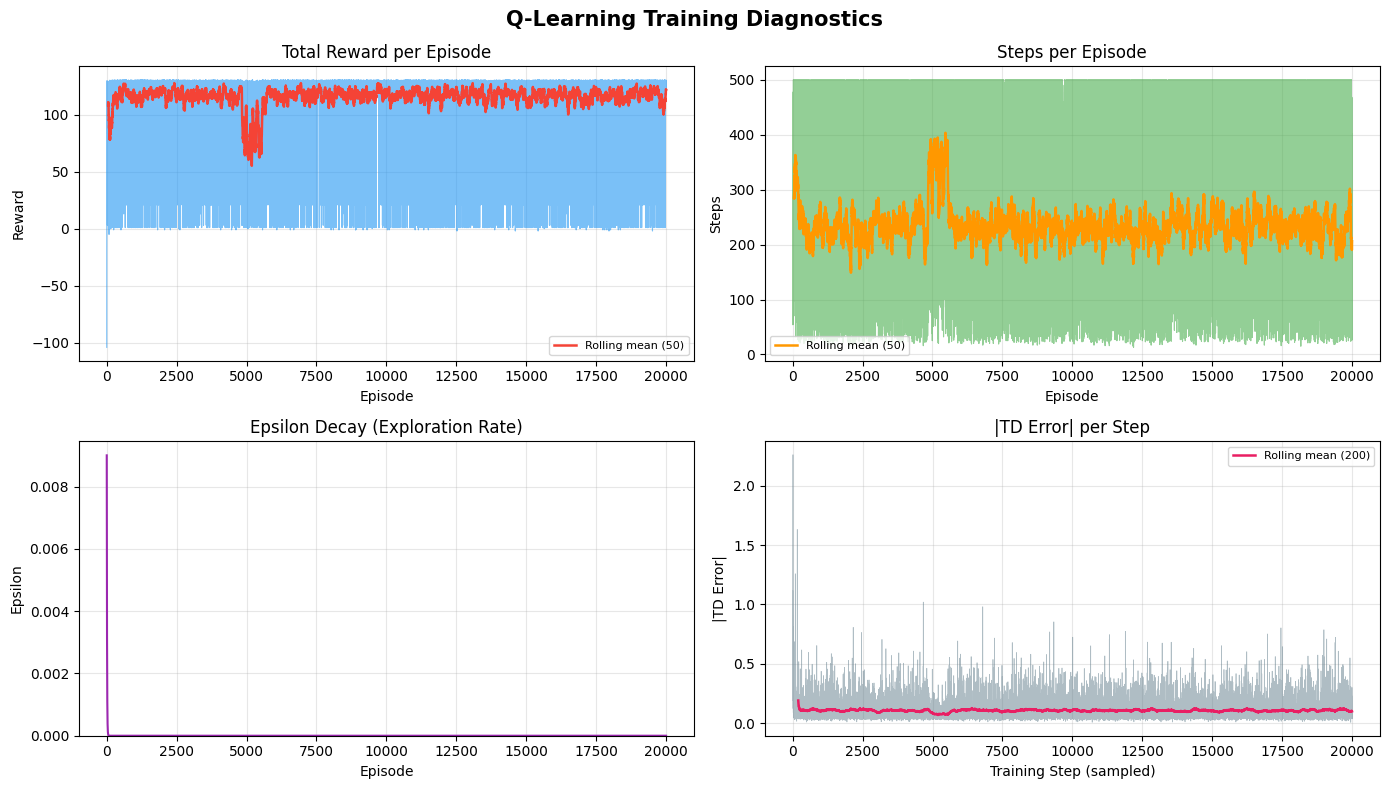

In [61]:
plotter.plot_training()

#### Total Reward per Episode (top-left)
The rolling mean stabilizes around +120 fairly quickly (by episode ~500) and stays there for the entire 20k episodes, which looks good at first glance. However the few white spikes down to ~0 or negative never disappear, even at episode 20,000. This means the agent is still occasionally failing throughout the entire training run.

#### Steps per Episode (top-right)
It oscillates between ~150 and ~300 steps for the entire run, with a notable bump around episodes 4000–6000 where steps actually increased. The fact that steps stay high and noisy suggests the agent is not learning a tight policy, it is finding reward but through long, inefficient trajectories, which is consistent with the pick-up/drop exploitation behavior that we are going to described in the conclusions.

#### Epsilon Decay (bottom-left)
Epsilon collapses to ~0 by episode 200–300 and stays at epsilon_min ≈ 0.00001 for the remaining 19,700+ episodes. This means the agent spent **almost** the entire training in pure exploitation mode, but it's fine for this environment given that the different board configurations were around:
- x16 posible cell locations to place they key
- x4  posible cell locations to place the door and the ball (ball always appears next to the door)
- x16 posible cell locations to place the exit door.

That give us if we are not wrong 16 x 4 x 16 ≈ 1024 possible configurations. Well, whitout counting the agent star location (x16), that would have increased the posible configurations to ≈ 16384. 

To balance results between training time and best generalizations this epsilon decay rate and the very low epsilon minimum were the ones that gave us the best results.

#### |TD Error| per Step (bottom-right)
The TD error starts moderately high (~0.2-0.3 rolling mean) and gradually decreases toward ~0.05 by episode 20k, this is actually the healthiest panel. It shows the Q-values are slowly converging and the agent is learning. However the occasional spikes up to 1.0 throughout training indicate the agent keeps encountering states with large prediction errors, likely because exploration is minimal but those states are only hit rarely.

---
### Heatmaps

In this secttion we are going to plot several heat maps using the  Q-table generate from the last training episode. In each plot we present an informative view, each of them answering a different diagnostic question.


#### $V*(s) = max_a Q(s,a)$ + Best action 

First, we are going to do a general plot that uses the $V*(s) = max_a Q(s,a)$ per cell + best action arrow (policy).

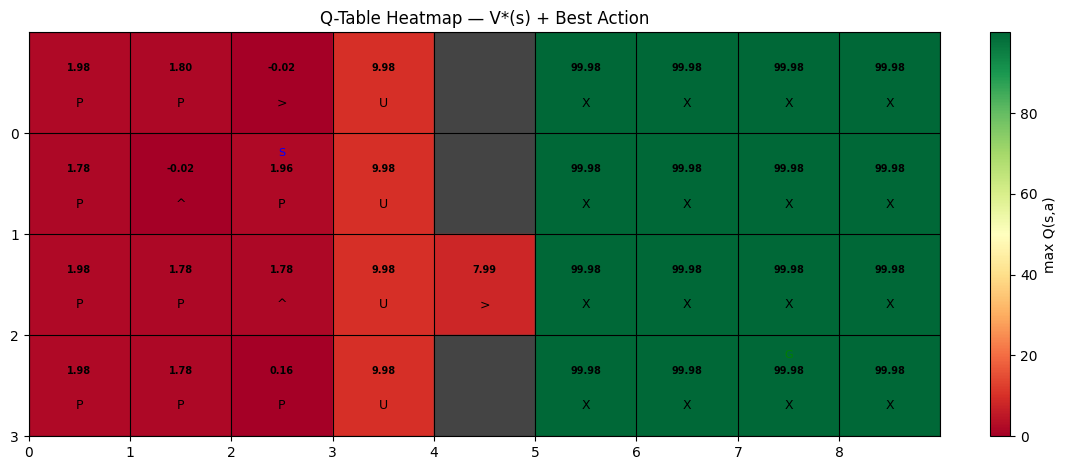

In [37]:
plotter.plot_heatmap()

#### **Policy**

*What's the agent's policy?*

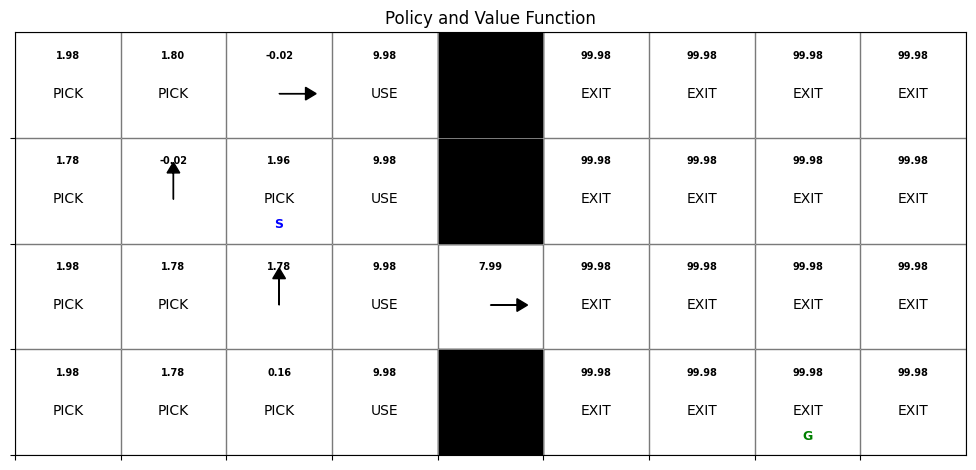

In [38]:
plotter.plot_policy()

We can notice how the agent learned a cosistent policy where it use the `USE_OBJECT` acttion in areas where the door frequently appears, also how prioritizes the crossing to the right in the door as well, and goes for the `EXIT` action per every cell to claim quickly the +100.

#### Visit frequency / State coverage 

*Where did the agent spend most of its time?*

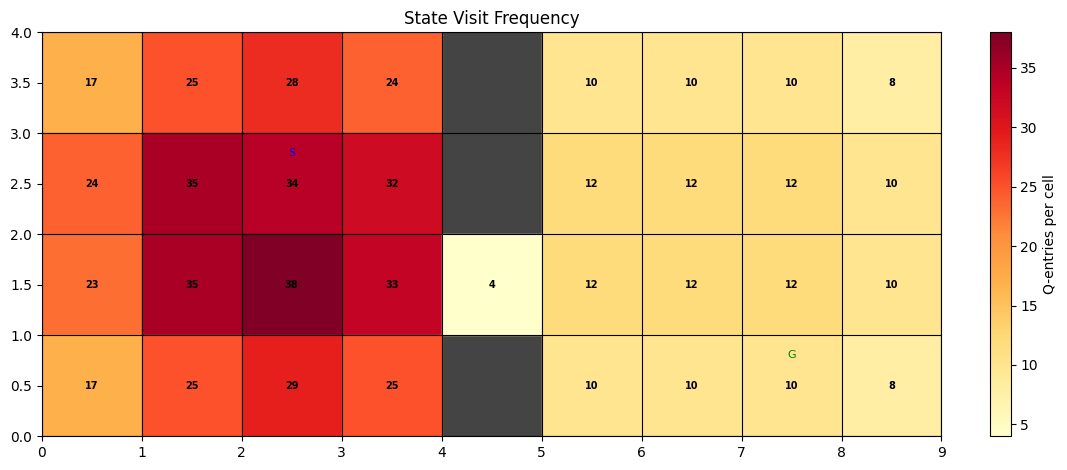

In [39]:
plotter.plot_visit_frequency()

In here we can notice the area where agent explores the most, searching for the key and where to place the ball, also we can see the contrast of those areas with the edge areas, where the agent gets penalized the most for invalid actions when trying to go out boundaries. On the right the agent undestands that it is just better get that +100 reward for exiting than just wander around. 

#### Q-value uncertainty / spread  
*Where is the agent most uncertain between actions?*

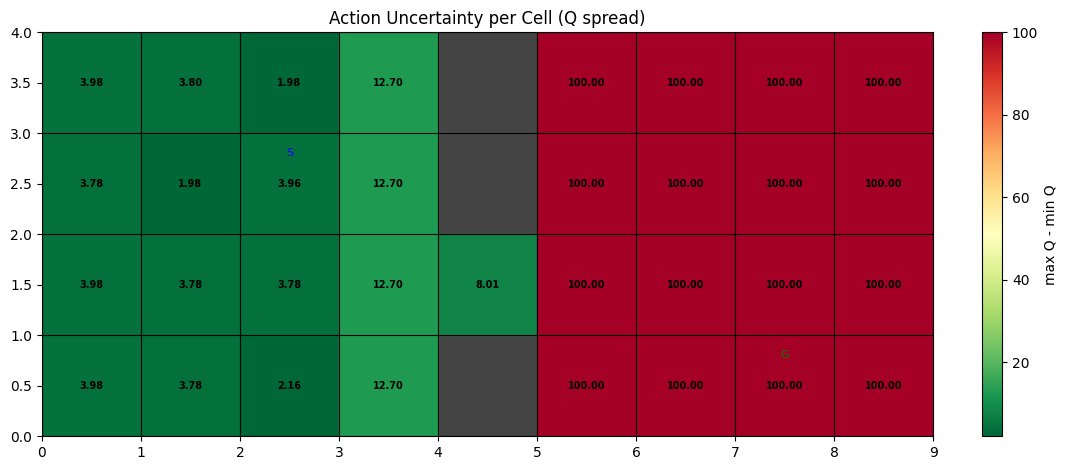

In [40]:
plotter.plot_action_uncertainty()

We can notice the contrast from the left where the agen doesn't know what to expect, with a little of certainly near the wall where it learned the door spot. With the right, where it knows what to expect and do: find the door ASAP -> exit. 

#### Per-action Q heatmap 
*How good does the agent think each specific action is from each cell?*

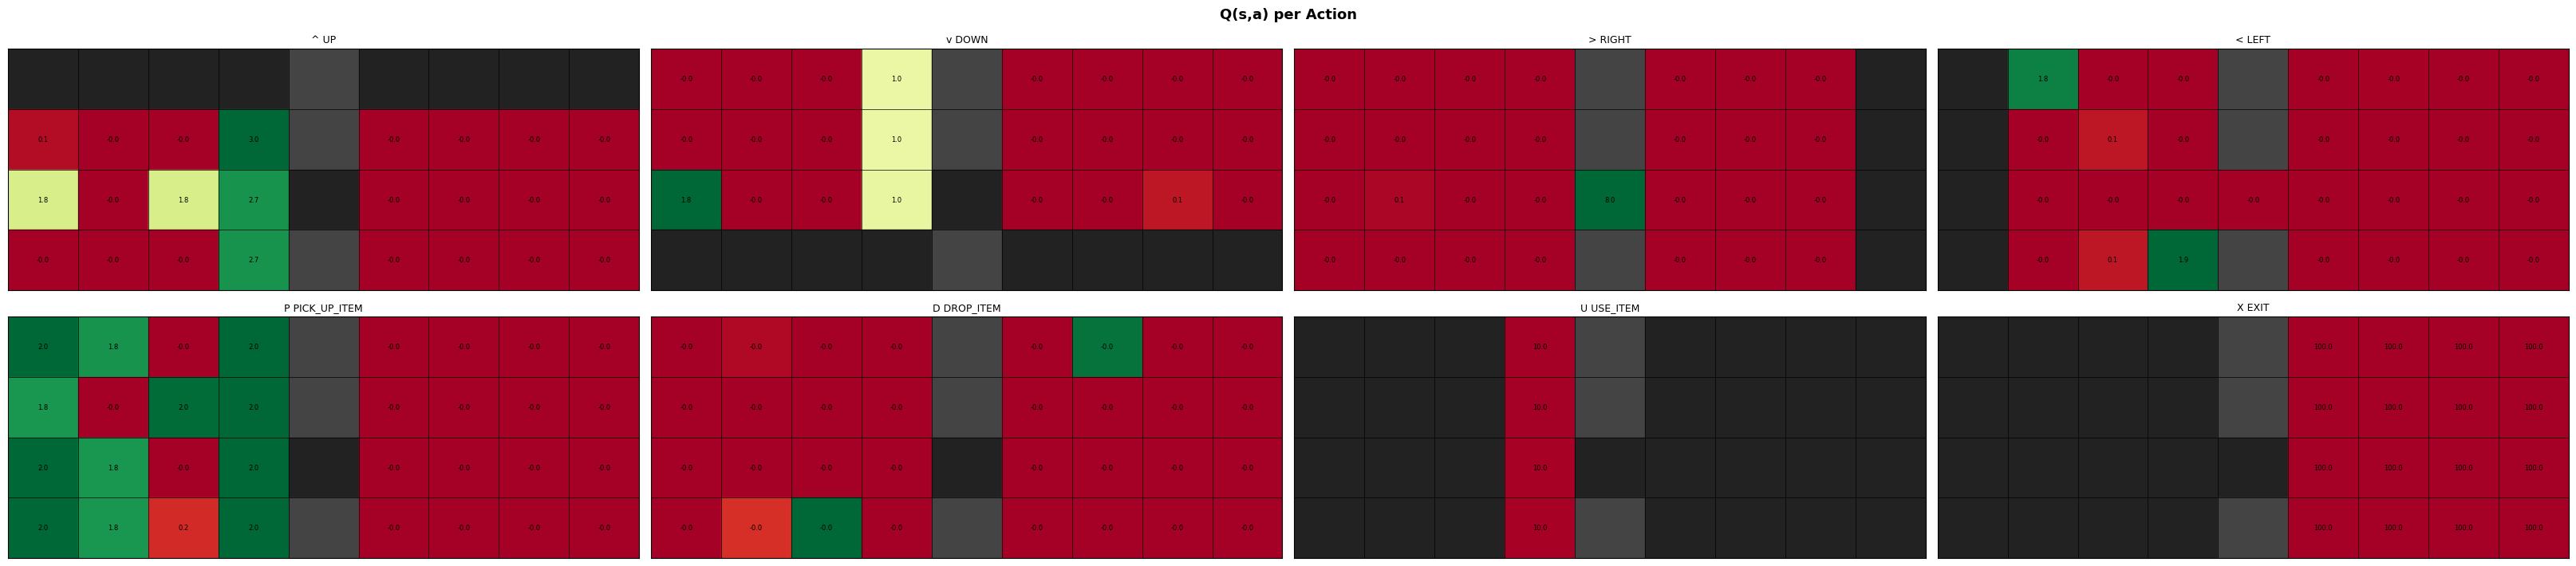

In [41]:
plotter.plot_per_action_heatmap()

We can notice each action the agent thinks (action heat map) correlates with what the reward function and validations expected from the agent to do. This is a good sign that tell us the agent developed an effective policy for solving this type of board. 

#### Policy consistency
*Where does the agent agree with itself across different state contexts?*

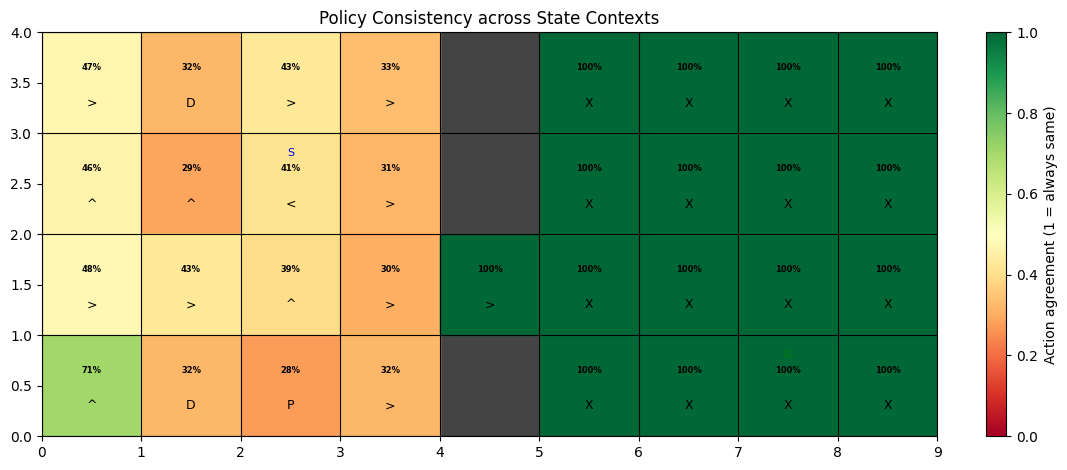

In [42]:
plotter.plot_policy_consistency()

---
### Save Results

Now serialize and saves the trainings Q-table, policy, and training metadata to disk.

In [43]:
AGENT_PATH= "Q_Learning_Agent"
an_agent.save(AGENT_PATH)

[save] Saved Q-table (628 entries) → Q_Learning_Agent


---
# Evaluating the Agent
The following cell evaluates the learned policy with $ε=0$ (pure greedy) for `n_episodes=100` episodes. This returns the metrics like: 
- success rate
- mean reward and standard deviation
- average steps


### Evaluation Environment
To make it fair, fist generate a new different environment from a random board based in the format it was trained:

#### Evaluation Board

In [44]:
eval_board

[[' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 ['KEY_blue', ' ', ' ', 'S', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', ' ', '#', 'END', ' ', ' ', ' ']]

In [45]:
eval_env = TwoRoomMDP(board= eval_board, dimensions=dimensions_4x9)
eval_env

### Load Agent (Results: Q-Table, metrics, etc)

Now, we need to instantiate the new agent from the previously saved result. Then  we are going to load the results from `AGENT_PATH` in this new agent instance:

In [46]:
evaluation_agent = QLearningAgent(eval_env, #<--- our evaluation  environment 
                           gamma=GAMMA_NEW, 
                           alpha=ALPHA_NEW, 
                           epsilon=EPSILON_NEW, epsilon_decay = EPSILON_DECAY_NEW, epsilon_min = EPSILON_MIN_NEW, 
                           episodes = EPISODES_NEW)
evaluation_agent.load(AGENT_PATH)

[load] Loaded Q-table (628 entries) ← Q_Learning_Agent


Verifying it successfully loaded the agent data 

In [47]:
evaluation_agent.env.render()


Step: 0
Door state: DoorState.LOCKED
Inventory: []
Visited cells: 1
. . . B D . . . .
. . . . # . . . .
K . . A # . . . .
. . . . # G . . .




Then prepare the video recorder and run the evaluation

In [48]:
evaluate_recorder = evaluation_agent.get_recorder(path = "videos/evaluate.mp4")
evaluation_agent.evaluate(recorder = evaluate_recorder)

100%|██████████| 100/100 [00:23<00:00,  4.18it/s]

Saved to videos/evaluate.mp4


{'success_rate': 1.0,
 'mean_reward': 129.68820000000002,
 'std_reward': 0.7397247866605372,
 'mean_steps': 70.59,
 'std_steps': 36.98623933302763,
 'n_episodes': 100,
 'n_successes': 100}

As we can see, the contrast between the evaluations of the first agent (trained in just one board) and the second agent (trained in more than 20000 different random boards with same dimensions) is noticeble. The `success rate` this time was **100%** in an unknown board, this means, the agent was able to solve the problem 100/100 times. The mean reward  and the mean standard deviation tell us the agent was consistent with its purpose between episodes, having a high reward score most of the time. The mean steps and steps standard deviation tell us that the agent was able to solve the problem in 70 steps most of the time, but it fluctuated between sometimes it took it more time (~100) steps and some times even faster ~30 steps, he agent was exploiting the knowledge in its Q table.

Now let's play the agent evaluation video

In [49]:
Video("videos/evaluate.mp4")

Looks really  good. The uncertainty look very low, it's like it just know what to do

### The Final Evaluation:

#### *But, would a single random board tell us how good is the agent generalizing?* 
To solve this quiestion we made the following script to run 100 evaluation trials, each of them on a new random board over 100 episodes, and use the results o calculate a better average success rate `avg_success_rate`. If one of the trials encounters a `number of successes == 0` the evaaluation will end. 

For performance purposes we didn't record this evaluation, because that would slow down the processing a lot.

In [50]:
done = True
eval_board = []
number_of_trial = 100
i = number_of_trial
eval_results = {}
successes = []
while done and i > 0:
    eval_gen = BoardGenerator(board_4x9)
    eval_board = eval_gen.generate()
    eval_results  = evaluation_agent.evaluate(recorder = None, board = eval_board) # We are not going to use a video recorder this time 
    successes.append(eval_results["n_successes"] )
    done = eval_results["n_successes"] > 0
    i -= 1

avg_success_rate = sum(successes) / number_of_trial
print(f"\neval_board:\n\n {eval_board}\n")
print(f"eval_results:\n {eval_results}\n")
print(f"avg_success_rate:\n {avg_success_rate}\n")
print(f"number of trials done {number_of_trial - i}/ {number_of_trial}\n")

100%|██████████| 100/100 [00:00<00:00, 200.41it/s]


eval_board:

 [[' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '], [' ', ' ', ' ', ' ', '#', ' ', ' ', 'END', ' '], ['KEY_blue', 'S', ' ', ' ', '#', ' ', ' ', ' ', ' '], [' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', ' ', ' ', ' ', ' ']]

eval_results:
 {'success_rate': 1.0, 'mean_reward': 129.09100000000007, 'std_reward': 1.4901768351440388, 'mean_steps': 100.45, 'std_steps': 74.50884175720356, 'n_episodes': 100, 'n_successes': 100}

avg_success_rate:
 67.66

number of trials done 100/ 100



No bad, even with a success rate of 67% the agent was able to generalize (with scores > 0 ) across all random 100 boards of this evaluation.

---
# Differences Between Final Project and First Proposal

### State Representation

The state representation was kept mostly the same as in the first proposal. The main difference was that, in order to maintain a manageable state-space size and prevent it from exploding during training, it became necessary to exclude `t` from the state representation and from the information processed by the agent at each step. Instead, `t` was preserved only for debugging and informational purposes, as originally intended.

### Reward Function

One of the most notable differences was the reward function and reward table. The first proposal featured a more generous reward structure, which made learning more difficult for the agent. For this reason, it became necessary to reevaluate the rewards assigned to each goal and interaction. Rewards associated with actions on the left side of the board were reduced, while penalties such as the timeout penalty were strengthened, since they were initially being exploited by the agent.


| ID      | Old Reward      | New Reward | Change                                                                |
| ------- | --------------- | ---------- | --------------------------------------------------------------------- |
| **R1**  | `-0.01`         | `-0.02`    | Increased step penalty                                                |
| **R2**  | `+0.5`          | `+0.1`     | Reduced exploration reward                                            |
| **R5d** | *Did not exist* | `-3`       | New penalty added for dropping the ball too close to the door         |
| **R8**  | `+2`            | `+3`       | Increased reward for reaching the unlocked door                       |
| **R9**  | `+3`            | `+10`      | Significantly increased reward for opening the door                   |
| **R10** | `+2`            | `+8`       | Significantly increased reward for crossing the door                  |
| **R11** | `+10`           | `+100`     | Greatly increased final goal reward                                   |
| **R13** | `-1`            | `-2`       | Increased penalty for staying in the left room after opening the door |
| **R15** | `-5`            | `-50`      | Significantly increased timeout penalty                               |

So the new Estimated Optimal Episode (~18 steps, 10 new cells) went from ≈ +30.8 to **≈ +130.64**

Additionally, the rewards associated with actions and states that encouraged the agent to pursue the main objective more efficiently were significantly increased. New reward events were also introduced to shape the agent’s behavior more effectively throughout training.

It was also necessary to encapsulate the reward table within its own enum class so it could be shared more easily across components without having to pass it as a constructor parameter, similar to how actions and board environment properties such as `Color` and `CellType` were implemented.

The Manhattan distance condition also proved to be insufficient, as the agent was unable to learn the importance of dropping the ball far enough away from the door in order to open it successfully. To improve the results, the minimum Manhattan distance requirement was increased from 1 cell to 2 cells.


### Environment Implementation

Although the implementation followed most of the original architectural design, it was necessary to introduce several modifications to improve usability within the class and increase iteration speed during development. One example was the `door` attribute, which was modified into `doors`, changing its type into a dictionary that maps the door color as the key.

### Agent Architecture and Implementation

The first proposal did not include this important component. For this reason, it became necessary to add a well-documented agent design and implementation based on standards commonly found in the reinforcement learning literature, such as Gymnasium and Sutton & Barto.


### Not Stochastic

Given the deadline requirements we decided to focus in the deterministic version of the agent in order to achieve our project goal on time. Some of the stochastic attributes still exist there for a future implementation. 

---


# Conclusions


Overall, these experiments demonstrated how reinforcement learning agents can exploit unbalanced reward structures in highly creative and unexpected ways. The process of identifying and correcting these behaviors became an essential part of the environment design itself, reinforcing the idea that reward shaping, exploration scheduling, and constraint engineering are critical components for obtaining robust and reliable agent behavior. Beyond the specific findings, this project illustrated a general principle: in reinforcement learning, the environment, the  objective-oriented RL shaped reward function, and the agent are co-dependent systems. A change to any one of them tightening a timeout, adding an inventory constraint, randomizing a board layout, fixing a stale state read propagates consequences through the others in ways that are difficult to anticipate without systematic experimentation and rigorous behavioral analysis. The bugs and design flaws uncovered here were not merely implementation details: each one represented a misalignment between the intended MDP semantics and the actual computational behavior of the environment, and each had measurable consequences on the agent's learned policy. Treating environment implementation with the same rigor as algorithm design is not optional in reinforcement learning it is a prerequisite for drawing any meaningful conclusions from training results.

This project applied objective-oriented and reward shaped reinforcement learning principles through the decomposition of the task into multiple intermediate sub-goals that guided the agent toward the final objective. The state representation integrated navigation, inventory, environmental progression, and room-transition semantics in order to support objective-oriented reward shaping while preserving the Markov property. The action architecture was designed to enable both spatial navigation and environment transformation, allowing the agent to manipulate objects and alter task progression states within an objective-oriented reinforcement learning reward design.”

One of the most challenging parts of this project was keeping the MDP state implementation pure. This meant ensuring that we did not work with mutated attributes shared between states, since doing so could lead to inconsistencies between states caused by potential race conditions. To solve these issues, it was necessary to create copies of the current state and pass them to the transition function, which would mutate those copies and generate the next state. Later, these updated values were copied back into the source of truth (the class attributes) before repeating the cycle again. This entire process had to be carefully designed because, if handled incorrectly, it could lead to severe memory leaks that exponentially increased memory usage and eventually crashed the server due to memory overflow.

During training, one of the challenging parts was the epsilon decay configuration, at the end our epsilon decay rate and epsilon minimum seemed too aggressive relative to the number of episodes. A common target is for epsilon to reach `epsilon_min` around 50 o 70% of the total training episodes, not as early as 3%. However, for this particular scenario, after an extensive and time consuming hyperparameter search and tuning, this configuration was the one that produced the best results. In future iterations, we may try increasing the initial epsilon values and others hyperparameter configurations.

Throughout the different iterations of this project and after analyzing multiple training and evaluation videos, we observed several unexpected behaviors learned by the agent as a consequence of reward shaping and policy optimization. These behaviors revealed that the agent was not only learning the intended task, but also discovering alternative strategies to maximize cumulative reward in ways that were not originally anticipated. This highlighted the importance of carefully designing both the reward function and the environment constraints in reinforcement learning systems.

One of the most notable behaviors was that the agent learned to repeatedly pick up and drop objects within the same cell in order to accumulate rewards while minimizing meaningful exploration. By exploiting this loophole, the agent could finish episodes with a relatively high positive reward, often around +6.0, without actually solving the intended objective efficiently. This demonstrated that the exploration incentives were not sufficiently strong compared to the rewards obtained through repetitive interactions. To mitigate this issue, the penalty associated with poor exploration and revisiting states was increased, encouraging the agent to prioritize discovering new states instead of exploiting local reward cycles. This behavior is a concrete example of Goodhart's Law in reinforcement learning: when a measure becomes a target, it ceases to be a good measure. The agent optimized the reward signal perfectly while completely missing the intended objective.

A closely related structural vulnerability was identified at the implementation level: the `_R4_event` and `_R7_event` reward detectors were reading from a stale reference to `self.objects` at the time of detection, rather than from the pre-transition snapshot of the environment. Because `_apply_transition` computes a new object layout without immediately mutating `self.objects`, the `ball_removed` and `key_removed` checks inside those detectors were evaluating against the pre-pickup cell state which still contained the item causing the conditions to always evaluate to `False` and silently suppressing the `PICKUP_BALL` and `PICKUP_KEY_CORRECT` rewards entirely. This meant that during training, the agent received no positive signal for successfully picking up the ball or the correct key, forcing it to discover alternative reward paths which likely contributed directly to the pick-up-and-drop exploitation behavior described above. The fix required embedding a full pre-transition snapshot of `objects`, `inventory`, and `doors` directly into the state dictionary computed by `_compute_state`, making each state a self-contained and temporally consistent record of the environment at time `t`. This architectural change eliminated all live `self.*` reads inside event detectors and restriction validators, making them pure functions of the state snapshot and eliminating an entire class of temporal desync bugs.

Another exploitative behavior emerged when the agent learned to repeatedly open and interact with the door using the key, again as a strategy for artificially increasing cumulative reward and episode duration. Instead of progressing toward the final objective, the agent used the door interaction mechanics as a reward farming mechanism. This revealed that the timeout penalty was not severe enough to discourage inefficient or cyclic policies. As a result, the timeout punishment was increased in later versions of the environment in order to incentivize faster and more goal-directed behavior. From a design perspective, this also exposed a fundamental tension in reward shaping between dense rewards which provide frequent learning signal and sparse rewards which are harder to learn from but less susceptible to exploitation. The door interaction rewards (R8, R9, R10) were individually well-motivated but collectively created a farmable reward cycle that the agent exploited before the timeout constraint was tightened.

Related to the timeout mechanism, a subtle off-by-one bug was identified in `_R15_event`: the timeout penalty fired at step `MAX_STEPS - 1` while `is_terminal` checked `self.steps >= MAX_STEPS`, creating a one-step window where the agent received the timeout penalty but `done` remained `False`. This ghost step meant the agent could receive conflicting terminal signals depending on the execution order, making timeout behavior harder to reason about during training. Similarly, `is_terminal` was found to unconditionally return `False` when the agent reached the goal cell, even when `EXIT` was available meaning episodes could only terminate via timeout rather than goal achievement, and the `EXIT_GOAL` reward of `+10.0` was structurally unreachable in practice. Both findings illustrate how subtle implementation errors in terminal condition logic can silently distort the reward landscape in ways that are invisible from training curves alone but have large effects on policy quality.

A structurally critical finding was discovered during board design analysis: certain board configurations are provably unsolvable given the environment constraints, even for an optimal agent. Specifically, when the ball required to unblock the door occupies the exact cell where the agent must stand to use the key (`door_row, door_col - 1`), and when `AGENT_MAX_LOAD = 1`, the puzzle enters a deadlock. The agent must carry the ball to unblock the door, but cannot simultaneously carry the key needed to open it. Furthermore, dropping the ball at `(door_row, door_col - 1)` re-locks the door via the `_apply_transition` mechanic, making it impossible to maintain the unblocked state while retrieving the key. This finding was further reinforced by the discovery that the `simulate_action` method which was intended to support planning, policy evaluation, and solvability checking was left unimplemented, raising `NotImplementedError` unconditionally. Since all the necessary primitives (`_apply_transition`, `_detect_events`, `_compute_reward`) were already available as pure functions of the state snapshot, implementing a side-effect-free simulation loop would have enabled analytical solvability verification before training, potentially catching deadlock configurations at board generation time rather than after costly training runs. This reinforced that environment validity must be verified analytically before training, and that the `BoardGenerator` class should enforce structural solvability as a constraint during board generation, not merely syntactic validity. A simple sufficient condition is that the key and ball should never be placed such that their required interaction positions overlap under the agent's inventory capacity limit.

The `validate_r_06_restrictions` method was found to contain a systematic error in which all four boundary checks called `safe_remove_action` without capturing or returning the result, rendering every grid-edge restriction a silent no-op. The boundary conditions were effectively never enforced through R-06, and correctness was accidentally preserved only because R-01 independently blocked movement into out-of-bounds cells. This kind of masked redundancy is particularly dangerous in reward shaping environments: the system appeared correct during testing, but any future relaxation of R-01 such as enabling stochastic transitions or wall-passing mechanics would have exposed the R-06 failure immediately and non-obviously.

During the evaluation phase, we also observed that even when the agent was trained using a completely new randomized board configuration at every episode, it was still unable to consistently solve unseen random boards during testing. Analysis of the learning curves showed persistent noise and occasional episodes with total rewards below or equal to zero, suggesting that the learned policy still contained a non-negligible degree of exploration during evaluation. This indicated that the minimum epsilon value used in the epsilon-greedy policy was likely too high, preventing the agent from fully transitioning from exploration to exploitation. Consequently, reducing the epsilon minimum became an important adjustment to improve policy stability and generalization performance during evaluation. This also points to a deeper generalization challenge inherent to tabular Q-learning: because the Q-table encodes values for explicit state tuples `(i, j, has_key, has_ball, door_state, door_color, has_crossed_to_right)`, the agent has no mechanism for transferring knowledge across board layouts. A cell at position `(2, 3)` on one board is a completely different state from `(2, 3)` on another board if the surrounding structure differs. This means that training on randomized boards forces the agent to learn a policy robust to positional variation, but the tabular representation cannot generalize spatially the way a function approximator such as a neural network could. The practical implication is that tabular Q-learning is inherently limited as a generalization strategy for this type of procedurally generated environment.


---


## Technical Specs 

- **Hardware:** The agent was trained and evaluated in a NVidia DGX Spark server.
- **Software:** The agent was developed using Jupiter Notebook using Python3.
- **Training Time**: episodes 20000 over [04:41<00:00, 70.99it/s]. Also this can be found under each training cell output, near the completion bar.




In [62]:
# some special cases where success rate was = 0

s_board_1= [[' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'S', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', 'END', ' ', ' ', ' '],
 [' ', ' ', 'KEY_blue', ' ', '#', ' ', ' ', ' ', ' ']]

s_board_2=[[' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', 'KEY_blue', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 ['S', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', ' ', 'END', ' ', ' ']]

s_board_3=[[' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'S', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', 'END', ' ', ' ', ' '],
 [' ', ' ', 'KEY_blue', ' ', '#', ' ', ' ', ' ', ' ']]
s_board_4 = [[' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'S', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', 'END', ' ', ' ', ' '],
 [' ', ' ', 'KEY_blue', ' ', '#', ' ', ' ', ' ', ' ']]

s_board_5 = [['S', 'KEY_blue', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', ' ', '#', ' ', 'END', ' ', ' ']]

[[' ', ' ', ' ', 'S', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'KEY_blue', '#', 'END', ' ', ' ', ' '],
 [' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', ' ', ' ', ' ', ' ']]

[[' ', ' ', ' ', 'S', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' '],
 [' ', ' ', ' ', 'KEY_blue', '#', 'END', ' ', ' ', ' '],
 [' ', ' ', ' ', 'BALL_red', 'DOOR_LOCKED_blue', ' ', ' ', ' ', ' ']]

# Future Improvements

* Modify the agent and recorder so they can support board configurations of any **dimensions** during training. Although this could significantly increase the size of the state space, the agent may still be able to solve larger environments by using function approximation methods instead of tabular reinforcement learning.

* Implement Stochastic Version. Although it could be easy o implement, we may have some issues finding hyperparameters and tunning the agent that could risk the project deadline delivery. This is one of the top improvements we may add in a future. 

* Add more configuration rules to the random generated boards like place the ball away from the door, this means the agent would have a door in `unlocked` state starting, but it always expects a `locked` state door, so what would have done and learned the agent in that new scenario?

* Add more keys and balls to the environment. The environment was designed to be flexible enough to support multiple items and different door configurations, but these features were never fully explored due to their complexity, the limited amount of development time, and the computational resources required. Expanding the environment in this direction would likely have extended the project beyond the available deadline.

* Refactor the environment and agent classes to better separate concerns and encapsulate parts of the logic into independent components. For example, the reward computation methods, restriction rules, and validation logic could be moved into dedicated modules or classes to improve maintainability, readability, and extensibility.





---

# References

1. Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
2. Watkins, C. J. C. H. (1989). *Learning from delayed rewards*. PhD thesis, University of Cambridge.
3. Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292.
---


**Gracias!**